In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pathlib import Path

# Загрузка данных из CSV-файла
root_dir = Path("/content/drive/MyDrive/dataset")
df = pd.read_csv(root_dir / "Property_rent_merged 2.csv")

# Фильтрация строк, где расстояние до метро указано как "8 мин пешком" или меньше
df_filtered = df[df['metro_station'].str.contains(r'(\d+ мин пешком)', na=False)]
df_filtered['distance'] = df_filtered['metro_station'].str.extract(r'(\d+) мин пешком').astype(float)
df_filtered = df_filtered[df_filtered['distance'] <= 8]

# Подсчет количества помещений для каждой станции метро
station_counts = df_filtered['metro_station'].str.extract(r'м\. ([\w\s]+)')[0].value_counts()

# Выбор топ-3 станций метро
top_stations = station_counts.head(3).index.sort_values()

# Вывод результата
print(", ".join(top_stations))

Нарвская , Фрунзенская , Чернышевская 


<ipython-input-3-5ba3fbf52a98>:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df[df['metro_station'].str.contains(r'(\d+ мин пешком)', na=False)]
<ipython-input-3-5ba3fbf52a98>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['distance'] = df_filtered['metro_station'].str.extract(r'(\d+) мин пешком').astype(float)


In [ ]:
dataset = ImageDataset(root_dir="/content/drive/MyDrive/dataset", transform=transform)


NameError: name 'ImageDataset' is not defined

In [ ]:
# Шаг 1: Создание синтетического датасета
class LettersDataset(Dataset):
    def __init__(self):
        # Простейшие изображения 5x5, представляющие буквы K, M, N, L
        self.data = [
            (np.array([
                [1, 0, 1, 0, 1],
                [1, 1, 0, 1, 0],
                [1, 0, 0, 1, 0],
                [1, 0, 1, 0, 1],
                [1, 0, 0, 1, 0]
            ]), 0),  # K
            (np.array([
                [1, 0, 0, 0, 1],
                [1, 1, 0, 1, 1],
                [1, 0, 1, 0, 1],
                [1, 0, 0, 0, 1],
                [1, 0, 0, 0, 1]
            ]), 1),  # M
            (np.array([
                [1, 0, 0, 0, 1],
                [1, 1, 0, 0, 1],
                [1, 0, 1, 0, 1],
                [1, 0, 0, 1, 1],
                [1, 0, 0, 0, 1]
            ]), 2),  # N
            (np.array([
                [1, 0, 0, 0, 0],
                [1, 0, 0, 0, 0],
                [1, 0, 0, 0, 0],
                [1, 0, 0, 0, 0],
                [1, 1, 1, 1, 1]
            ]), 3)   # L
        ]
        self.data = [(torch.tensor(img, dtype=torch.float32).flatten(), torch.tensor(label)) for img, label in self.data]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Шаг 2: Определение архитектуры нейронной сети
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(25, 16)  # 25 входов (5x5 изображение), 16 нейронов в скрытом слое
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 4)  # 4 выхода (количество классов: K, M, N, L)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Шаг 3: Обучение модели
def train_model():
    dataset = LettersDataset()
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    epochs = 50
    for epoch in range(epochs):
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    return model

# Шаг 4: Тестирование модели
def test_model(model):
    test_dataset = LettersDataset()
    for inputs, label in test_dataset:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 0)
        print(f"True Label: {label.item()}, Predicted: {predicted.item()}")

# Запуск обучения и тестирования
model = train_model()
test_model(model)


Epoch 10/50, Loss: 0.8824
Epoch 20/50, Loss: 0.4402
Epoch 30/50, Loss: 0.2753
Epoch 40/50, Loss: 0.1700
Epoch 50/50, Loss: 0.0120
True Label: 0, Predicted: 0
True Label: 1, Predicted: 1
True Label: 2, Predicted: 2
True Label: 3, Predicted: 3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset = ImageDataset(root_dir="/content/drive/MyDrive/dataset", transform=transform)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# Создание кастомного Dataset
# В классе ImageDataset убедитесь, что метки правильно сопоставляются:
class ImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.classes.sort()  # Сортируем классы в алфавитном порядке
        self.data = []

        for class_idx, class_name in enumerate(self.classes):
            class_folder = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                self.data.append((img_path, class_idx))  # Сохраняем путь и метку

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("L")  # Ч/б изображение

        # Преобразуем метку с 1-4 в 0-3
        label = label  # Здесь мы должны удостовериться, что метки уже индексируются с 0!

        if self.transform:
            image = self.transform(image)
        print('label', label)
        return image, label



# Пример использования
transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Преобразование изображения в размер 28x28
    transforms.ToTensor(),        # Преобразование в тензор
    transforms.Normalize((0.5,), (0.5,))  # Нормализация (среднее = 0.5, стандартное отклонение = 0.5)
])

# Указываем путь к вашему датасету
dataset = ImageDataset(root_dir="/content/drive/MyDrive/dataset", transform=transform)

# Пример вывода
print(f"Количество изображений в датасете: {len(dataset)}")


Количество изображений в датасете: 16


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
import torch.nn as nn
import torch.optim as optim

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # Входной слой (размер 28x28)
        self.fc2 = nn.Linear(128, 4)        # Выходной слой (классы K, M, N, L)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Применение активации ReLU
        x = self.fc2(x)              # Выходной слой
        return x


In [ ]:
model = SimpleNN()  # Простая сеть из предыдущего примера
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение
for epoch in range(10):  # Количество эпох
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs.view(inputs.size(0), -1))  # Развёртывание 2D изображений в 1D
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


IndexError: Target 4 is out of bounds.

In [ ]:
# Пример тестирования
test_dataset = ImageDataset(root_dir="path_to_test_dataset", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for inputs, label in test_loader:
    outputs = model(inputs.view(inputs.size(0), -1))
    _, predicted = torch.max(outputs, 1)
    print(f"True Label: {label.item()}, Predicted: {predicted.item()}")


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_test_dataset'

In [ ]:
# Пример проверки меток в датасете
for inputs, labels in dataloader:
    print(labels)  # Напечатает метки, чтобы убедиться, что они от 0 до 3
    break  # Для одного батча


tensor([1, 2, 1, 3, 4, 3, 3, 2, 2, 1, 1, 3, 2, 4, 4, 4])


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import matplotlib as plt

# Шаг 1: Создание датасета с изображениями из файловой системы
class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # Используем ImageFolder для загрузки изображений
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Шаг 2: Определение архитектуры нейронной сети
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)  # 28x28 изображение (предполагаем, что изображения будут в формате 28x28), 128 нейронов в скрытом слое
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 4)  # 4 выхода (количество классов: K, M, N, L)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Преобразуем изображение в вектор
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Шаг 3: Обучение модели
def train_model():
    # Путь к папке с данными
    root_dir = "/content/drive/MyDrive/dataset"

    # Преобразования для изображений (масштабирование и преобразование в тензор)
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Преобразуем в оттенки серого, если изображения цветные
        transforms.Resize((28, 28)),  # Изменяем размер изображений до 28x28
        transforms.ToTensor(),  # Преобразуем изображение в тензор
        transforms.Normalize((0.5,), (0.5,))  # Нормализация для серых изображений
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 50
    for epoch in range(epochs):
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    return model

# Шаг 4: Тестирование модели
def test_model(model):
    # Путь к папке с данными
    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Преобразуем в оттенки серого
        transforms.Resize((28, 28)),  # Изменяем размер изображений до 28x28
        transforms.ToTensor(),  # Преобразуем изображение в тензор
        transforms.Normalize((0.5,), (0.5,))  # Нормализация
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))  # Добавляем batch размер
        _, predicted = torch.max(outputs, 1)
        imshow(inputs.cpu())
        print(f"True Label: {label}, Predicted: {predicted.item()}")


# Запуск обучения и тестирования
model = train_model()
test_model(model)


KeyboardInterrupt: 

In [ ]:
rm -r /content/drive/MyDrive/dataset/.ipynb_checkpoints


Epoch 10/50, Loss: 0.2177
Visualizing some sample images...


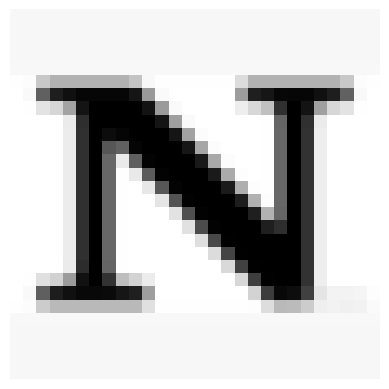

IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Функция для отображения изображений
def imshow(img):
    img = img.numpy()  # Преобразуем тензор в numpy массив
    img = np.squeeze(img)  # Убираем лишнюю размерность (если это изображение в оттенках серого, то размерность (1, H, W) будет -> (H, W))
    plt.imshow(img, cmap='gray')  # Показываем изображение в оттенках серого
    plt.axis('off')  # Убираем оси
    plt.show()

# Шаг 3: Обучение модели с отображением изображений
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Преобразуем в оттенки серого
        transforms.Resize((28, 28)),  # Изменяем размер изображений до 28x28
        transforms.ToTensor(),  # Преобразуем изображение в тензор
        transforms.Normalize((0.5,), (0.5,))  # Нормализация
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 50
    for epoch in range(epochs):
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

        # Отображаем несколько изображений каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            print("Visualizing some sample images...")
            imshow(inputs[0].cpu())  # Показываем первое изображение из пакета
            imshow(inputs[1].cpu())  # Показываем второе изображение из пакета

    return model

# Шаг 4: Тестирование модели с отображением изображений
def test_model(model):
    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Преобразуем в оттенки серого
        transforms.Resize((28, 28)),  # Изменяем размер изображений до 28x28
        transforms.ToTensor(),  # Преобразуем изображение в тензор
        transforms.Normalize((0.5,), (0.5,))  # Нормализация
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))  # Добавляем batch размер
        _, predicted = torch.max(outputs, 1)

        # Отображаем изображение
        imshow(inputs.cpu())  # Показываем изображение
        print(f"True Label: {label}, Predicted: {predicted.item()}")

model = train_model()
test_model(model)


Epoch 1/50, Loss: 1.7299
Epoch 1/50, Loss: 1.2017
Epoch 2/50, Loss: 1.3469
Epoch 2/50, Loss: 1.2594
Epoch 3/50, Loss: 0.8313
Epoch 3/50, Loss: 0.8886
Epoch 4/50, Loss: 1.3581
Epoch 4/50, Loss: 0.7975
Epoch 4/50, Loss: 0.8201
Epoch 5/50, Loss: 0.6780
Epoch 5/50, Loss: 0.5312
Epoch 6/50, Loss: 0.3568
Epoch 6/50, Loss: 0.6430
Epoch 7/50, Loss: 0.7237
Epoch 7/50, Loss: 0.6664
Epoch 7/50, Loss: 0.6977
Epoch 8/50, Loss: 0.5472
Epoch 8/50, Loss: 0.8763
Epoch 9/50, Loss: 0.3158
Epoch 9/50, Loss: 1.0591
Epoch 10/50, Loss: 0.2836
Epoch 10/50, Loss: 0.1643
Epoch 10/50, Loss: 0.1035
Epoch 11/50, Loss: 0.5794
Epoch 11/50, Loss: 0.2215
Epoch 12/50, Loss: 0.3258
Epoch 12/50, Loss: 0.4149
Epoch 13/50, Loss: 0.3530
Epoch 13/50, Loss: 0.2067
Epoch 14/50, Loss: 0.3804
Epoch 14/50, Loss: 0.2411
Epoch 14/50, Loss: 0.2217
Epoch 15/50, Loss: 0.1626
Epoch 15/50, Loss: 0.2780
Epoch 16/50, Loss: 0.2247
Epoch 16/50, Loss: 0.1288
Epoch 17/50, Loss: 0.1010
Epoch 17/50, Loss: 0.2323
Epoch 17/50, Loss: 0.0909
Epoch 

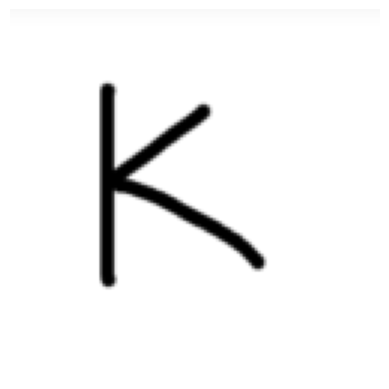

True Label: 0, Predicted: 0


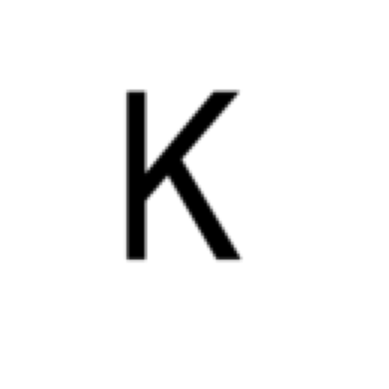

True Label: 0, Predicted: 0


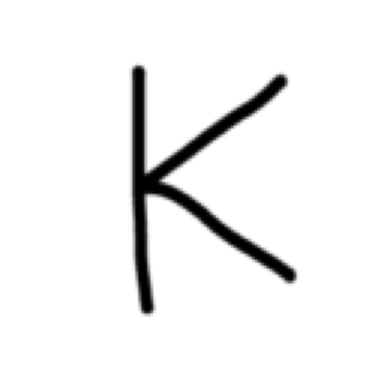

True Label: 0, Predicted: 0


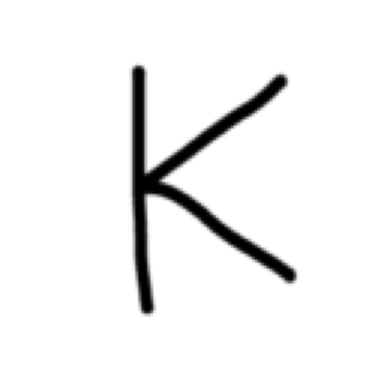

True Label: 0, Predicted: 0


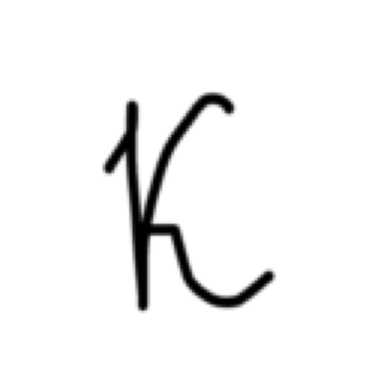

True Label: 0, Predicted: 1


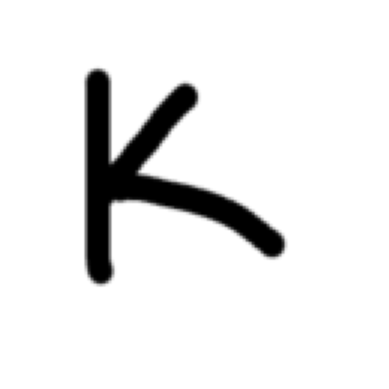

True Label: 0, Predicted: 0


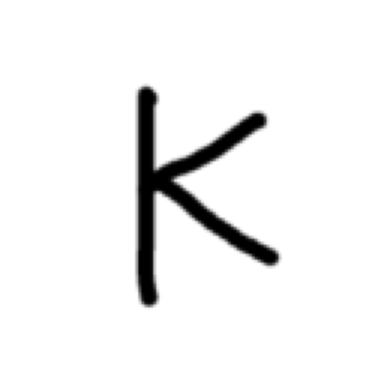

True Label: 0, Predicted: 3


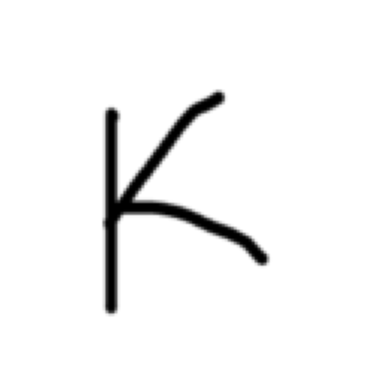

True Label: 0, Predicted: 0


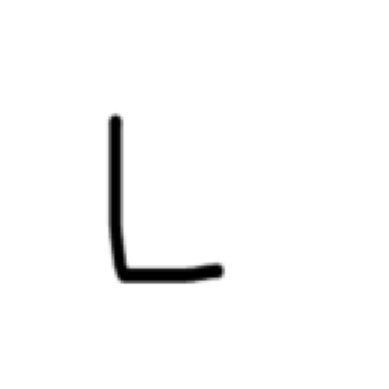

True Label: 1, Predicted: 1


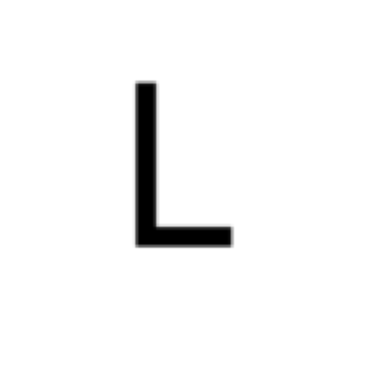

True Label: 1, Predicted: 1


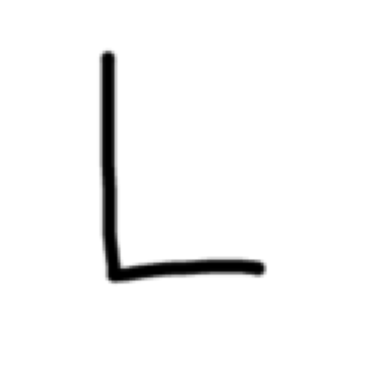

True Label: 1, Predicted: 1


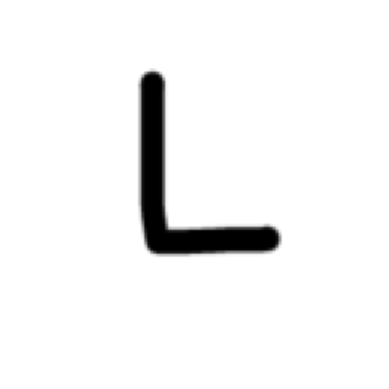

True Label: 1, Predicted: 1


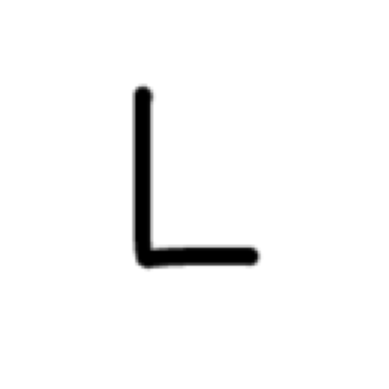

True Label: 1, Predicted: 1


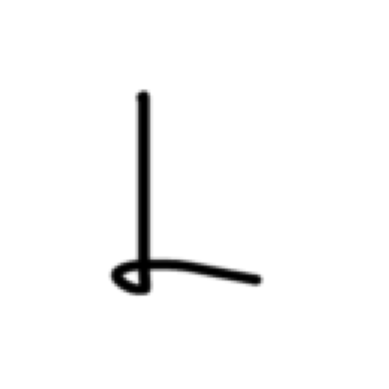

True Label: 1, Predicted: 1


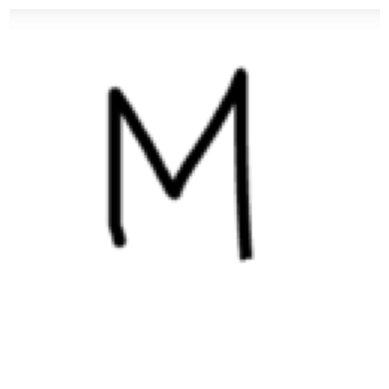

True Label: 2, Predicted: 2


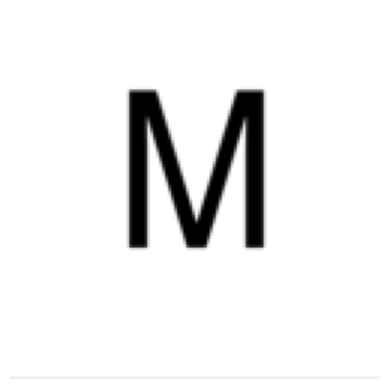

True Label: 2, Predicted: 2


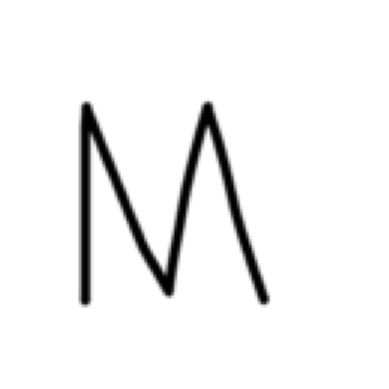

True Label: 2, Predicted: 2


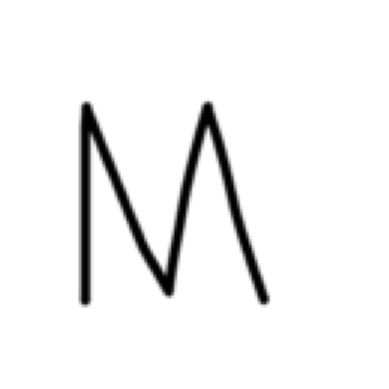

True Label: 2, Predicted: 2


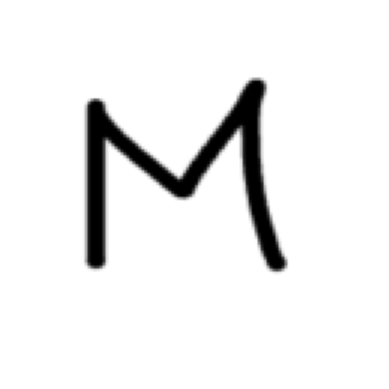

True Label: 2, Predicted: 2


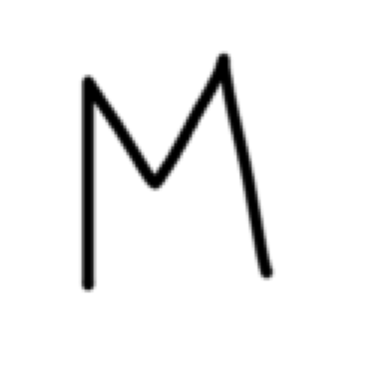

True Label: 2, Predicted: 2


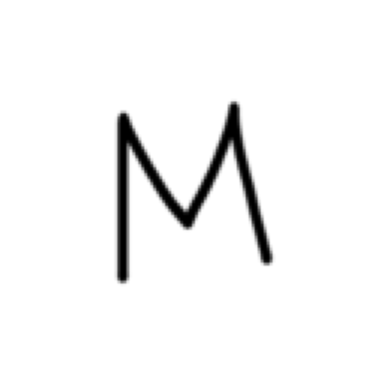

True Label: 2, Predicted: 2


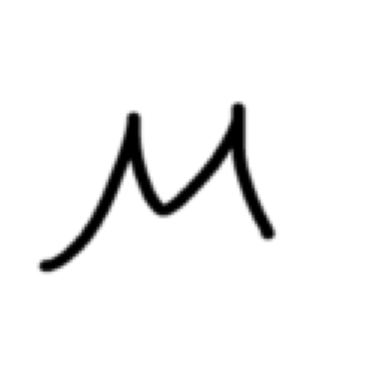

True Label: 2, Predicted: 2


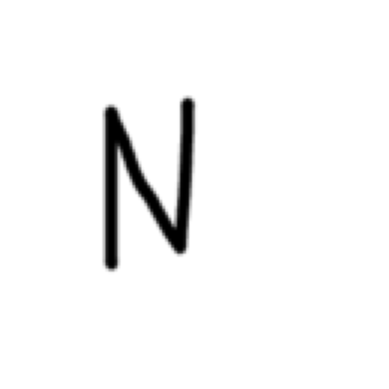

True Label: 3, Predicted: 0


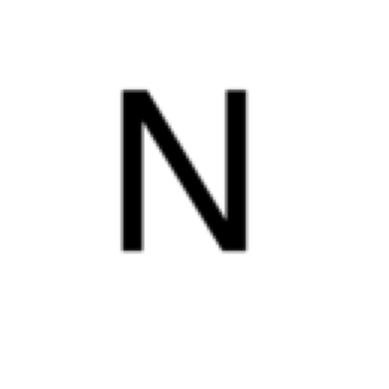

True Label: 3, Predicted: 3


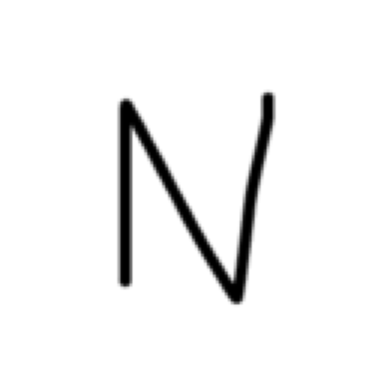

True Label: 3, Predicted: 3


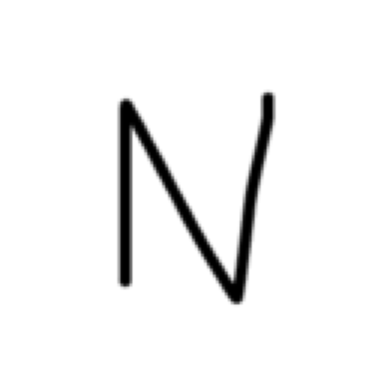

True Label: 3, Predicted: 3


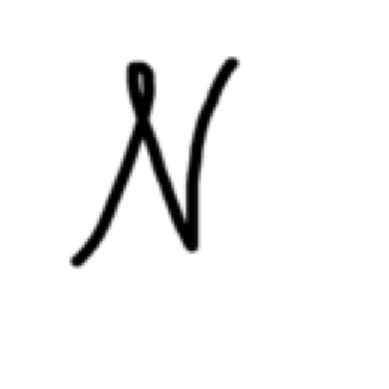

True Label: 3, Predicted: 3


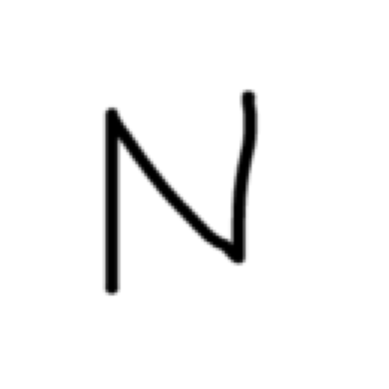

True Label: 3, Predicted: 3


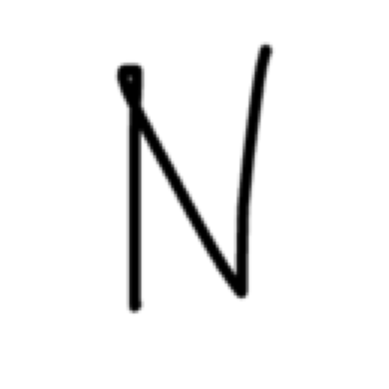

True Label: 3, Predicted: 3


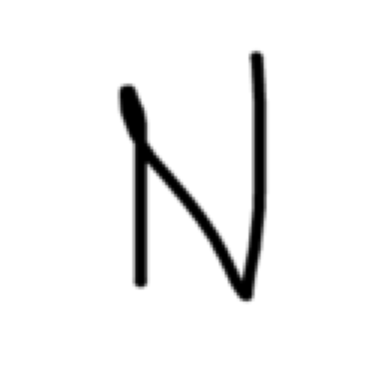

True Label: 3, Predicted: 3


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

#Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(124*124, 128), #входной слой
            nn.ReLU(),
            nn.Linear(128, 256), #скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), #выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), #даёт вероятностное значение для каждой буквы
        )



    def forward(self, x):
        x = x.view(-1, 124*124)  #Преобразуем изображение в вектор
        return self._model(x)

#обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((124, 124)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    #criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) #Adam использует метод статистически градиентного спуска
#lr - умножает на него
    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            if (iteration + 1) % 10 == 0:
                model.eval() #для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
            iteration += 1

    return model

# Тестирование
def test_model(model):

    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((124, 124)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        imshow(inputs.cpu())
        print(f"True Label: {label}, Predicted: {predicted.item()}")

model = train_model()
test_model(model)


Epoch 1/50, Loss: 1.3587
Epoch 1/50, Loss: 1.2206
Epoch 2/50, Loss: 0.9984
Epoch 2/50, Loss: 1.1742
Epoch 3/50, Loss: 1.0939
Epoch 3/50, Loss: 0.9863
Epoch 4/50, Loss: 0.8949
Epoch 4/50, Loss: 0.7745
Epoch 4/50, Loss: 0.6548
Epoch 5/50, Loss: 0.8040
Epoch 5/50, Loss: 0.8719
Epoch 6/50, Loss: 0.7389
Epoch 6/50, Loss: 0.7018
Epoch 7/50, Loss: 0.6318
Epoch 7/50, Loss: 0.5826
Epoch 7/50, Loss: 0.9387
Epoch 8/50, Loss: 0.3682
Epoch 8/50, Loss: 0.5386
Epoch 9/50, Loss: 0.5159
Epoch 9/50, Loss: 1.4509
Epoch 10/50, Loss: 0.6717
Epoch 10/50, Loss: 0.1806
Epoch 10/50, Loss: 0.2429
Epoch 11/50, Loss: 0.3897
Epoch 11/50, Loss: 0.4846
Epoch 12/50, Loss: 0.3434
Epoch 12/50, Loss: 0.2669
Epoch 13/50, Loss: 0.5260
Epoch 13/50, Loss: 0.6047
Epoch 14/50, Loss: 0.4530
Epoch 14/50, Loss: 0.2892
Epoch 14/50, Loss: 0.4899
Epoch 15/50, Loss: 0.2901
Epoch 15/50, Loss: 0.2231
Epoch 16/50, Loss: 0.1612
Epoch 16/50, Loss: 0.5117
Epoch 17/50, Loss: 0.3055
Epoch 17/50, Loss: 0.3987
Epoch 17/50, Loss: 0.1410
Epoch 

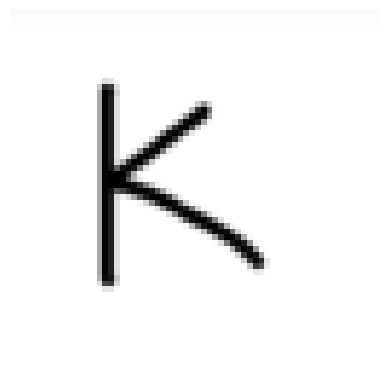

True Label: 0, Predicted: 0


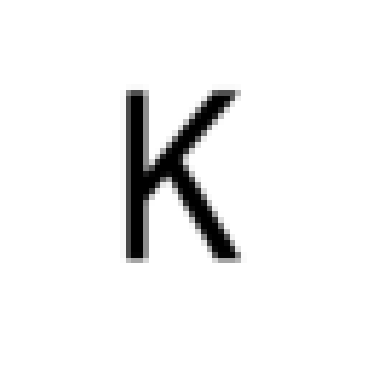

True Label: 0, Predicted: 0


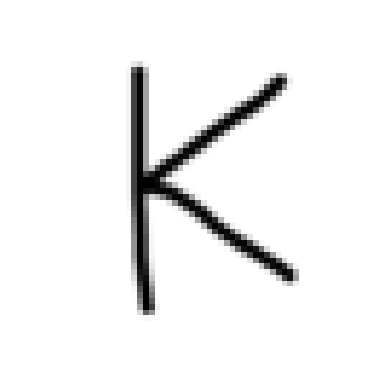

True Label: 0, Predicted: 0


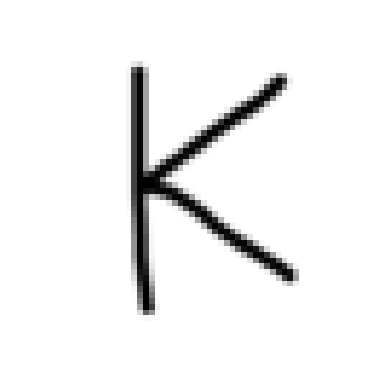

True Label: 0, Predicted: 0


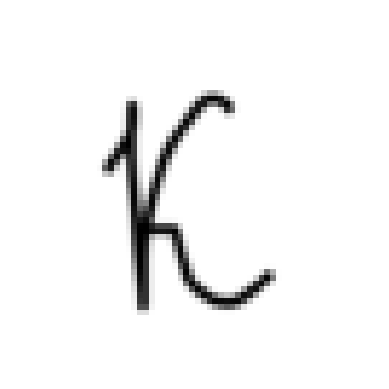

True Label: 0, Predicted: 1


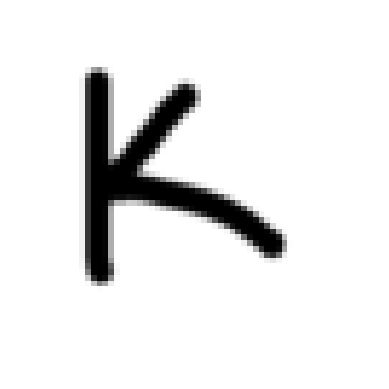

True Label: 0, Predicted: 0


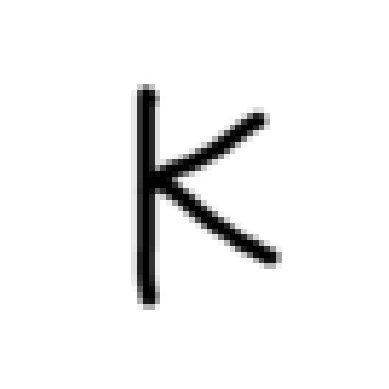

True Label: 0, Predicted: 0


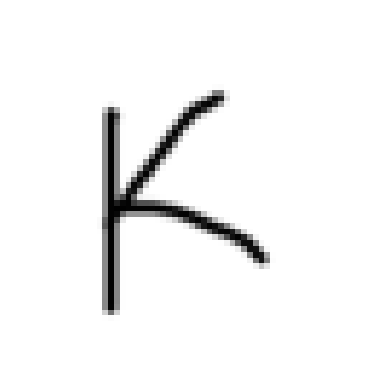

True Label: 0, Predicted: 0


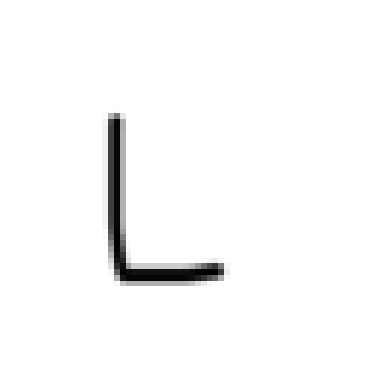

True Label: 1, Predicted: 1


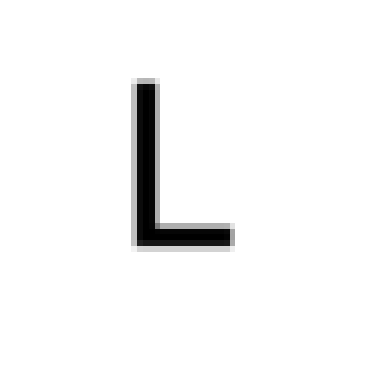

True Label: 1, Predicted: 1


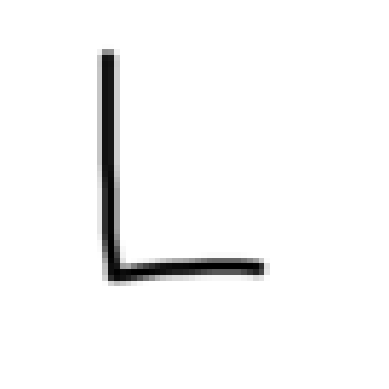

True Label: 1, Predicted: 1


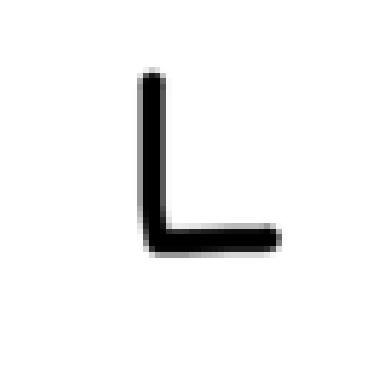

True Label: 1, Predicted: 1


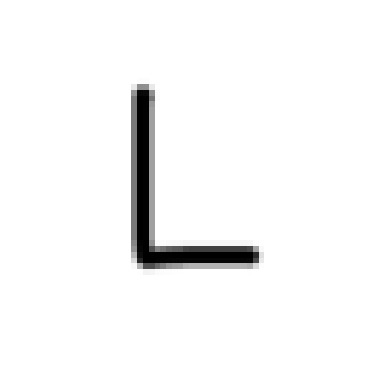

True Label: 1, Predicted: 1


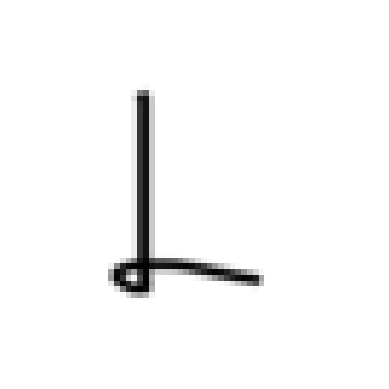

True Label: 1, Predicted: 1


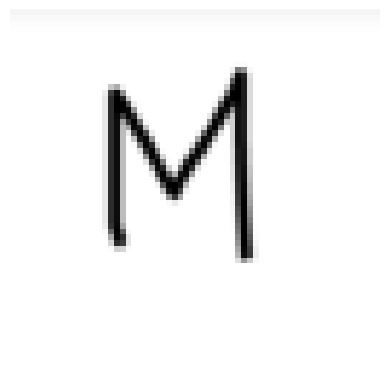

True Label: 2, Predicted: 3


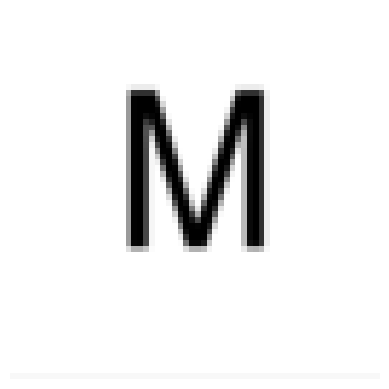

True Label: 2, Predicted: 2


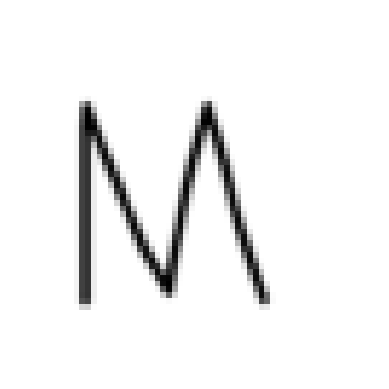

True Label: 2, Predicted: 2


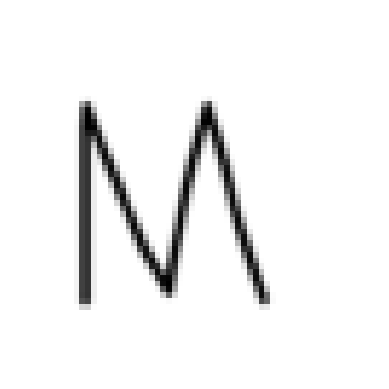

True Label: 2, Predicted: 2


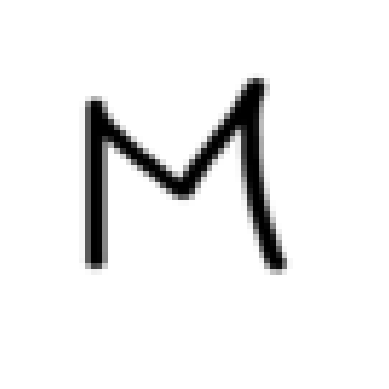

True Label: 2, Predicted: 2


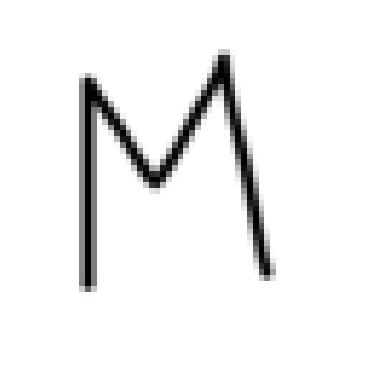

True Label: 2, Predicted: 2


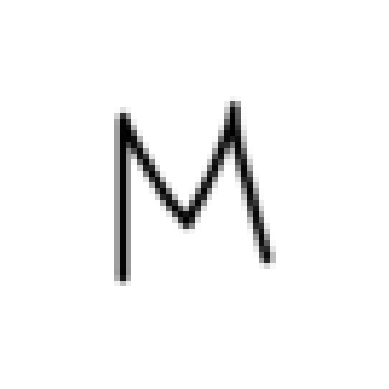

True Label: 2, Predicted: 2


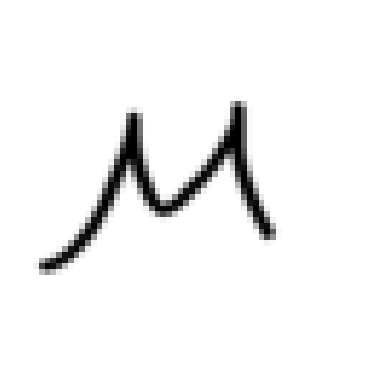

True Label: 2, Predicted: 2


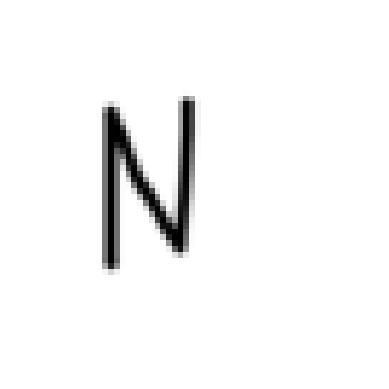

True Label: 3, Predicted: 0


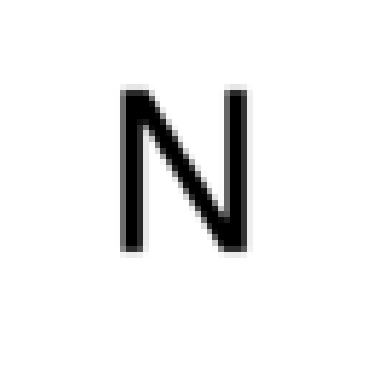

True Label: 3, Predicted: 3


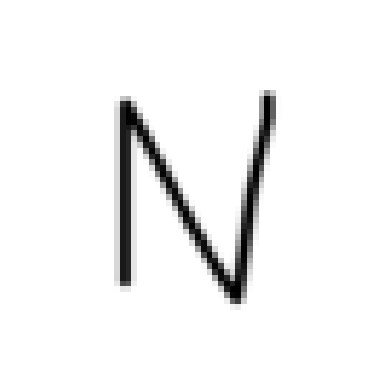

True Label: 3, Predicted: 3


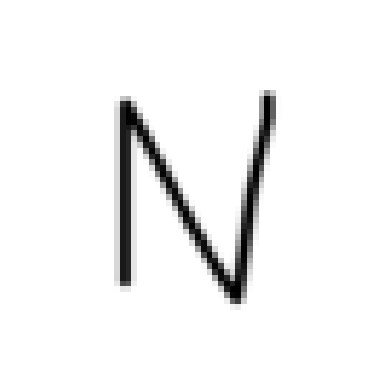

True Label: 3, Predicted: 3


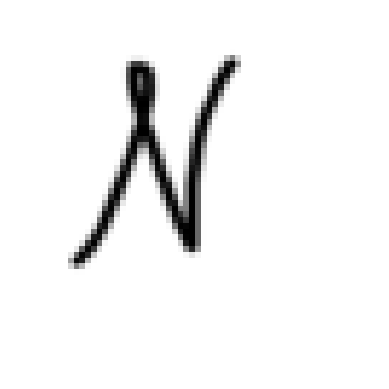

True Label: 3, Predicted: 0


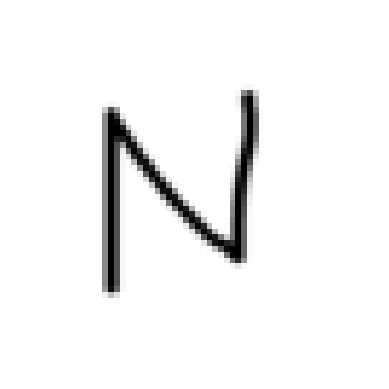

True Label: 3, Predicted: 3


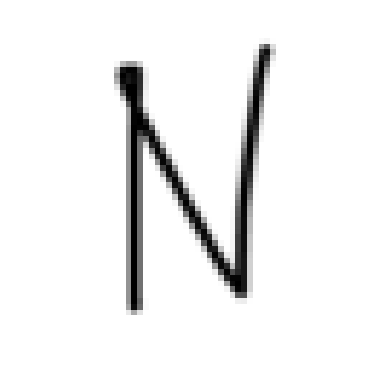

True Label: 3, Predicted: 3


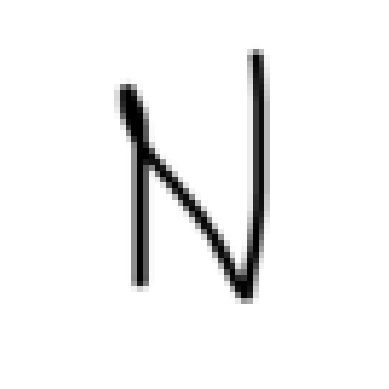

True Label: 3, Predicted: 3


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(64*64, 128), # Входной слой
            nn.ReLU(),
            nn.Linear(128, 256), # Скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), # Выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), # Даёт вероятностное значение для каждой буквы
        )

    def forward(self, x):
        x = x.view(-1, 64*64)  # Преобразуем изображение в вектор
        return self._model(x)

# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
            iteration += 1

    return model

# Тестирование
def test_model(model):

    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        imshow(inputs.cpu())
        print(f"True Label: {label}, Predicted: {predicted.item()}")

model = train_model()
test_model(model)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1/50, Loss: 1.3275, Accuracy: 24.00%
Epoch 1/50, Loss: 1.2853, Accuracy: 30.50%
Epoch 2/50, Loss: 1.4315, Accuracy: 34.00%
Epoch 2/50, Loss: 1.2646, Accuracy: 36.67%
Epoch 2/50, Loss: 0.9421, Accuracy: 38.55%
Epoch 3/50, Loss: 0.9851, Accuracy: 48.00%
Epoch 3/50, Loss: 1.2069, Accuracy: 52.50%
Epoch 4/50, Loss: 0.7473, Accuracy: 54.00%
Epoch 4/50, Loss: 0.9016, Accuracy: 56.00%
Epoch 4/50, Loss: 0.7680, Accuracy: 58.23%
Epoch 5/50, Loss: 0.6514, Accuracy: 68.00%
Epoch 5/50, Loss: 0.6725, Accuracy: 68.00%
Epoch 6/50, Loss: 0.7819, Accuracy: 76.00%
Epoch 6/50, Loss: 0.6889, Accuracy: 74.00%
Epoch 6/50, Loss: 1.0512, Accuracy: 73.90%
Epoch 7/50, Loss: 0.4750, Accuracy: 82.00%
Epoch 7/50, Loss: 0.6124, Accuracy: 81.50%
Epoch 8/50, Loss: 0.4022, Accuracy: 80.00%
Epoch 8/50, Loss: 0.3595, Accuracy: 80.00%
Epoch 8/50, Loss: 0.5797, Accuracy: 79.12%
Epoch 9/50, Loss: 0.2338, Accuracy: 83.00%
Epoch 9/50, Loss: 0.2743, Accuracy: 80.00%
Epoch 10/50, Loss: 0.6803, Accuracy: 78.00%
Epoch 10/5

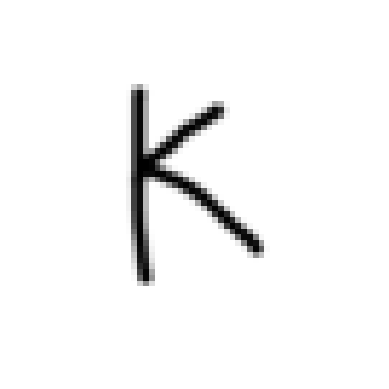

Predicted probabilities:
Class 0: 0.9999
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0001
True Label: 0



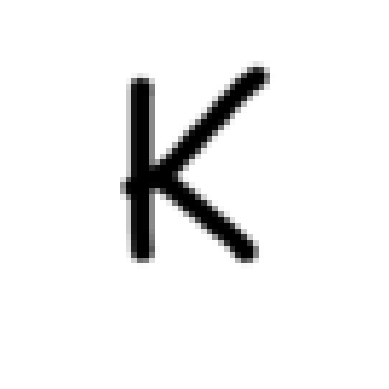

Predicted probabilities:
Class 0: 1.0000
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0000
True Label: 0



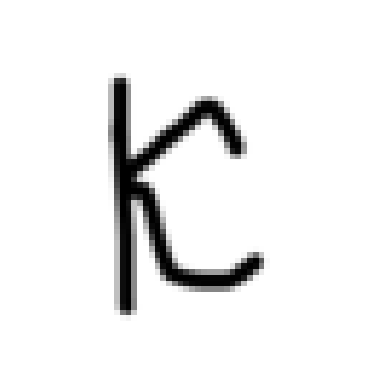

Predicted probabilities:
Class 0: 0.9980
Class 1: 0.0019
Class 2: 0.0000
Class 3: 0.0001
True Label: 0



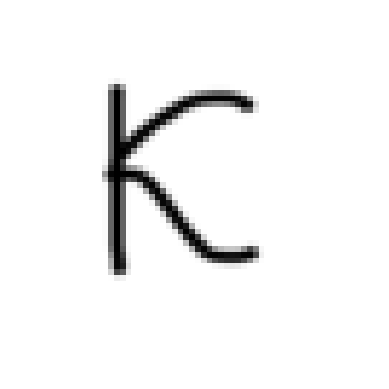

Predicted probabilities:
Class 0: 0.9991
Class 1: 0.0009
Class 2: 0.0000
Class 3: 0.0001
True Label: 0



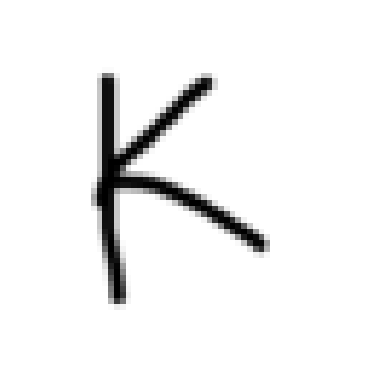

Predicted probabilities:
Class 0: 0.9999
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0001
True Label: 0



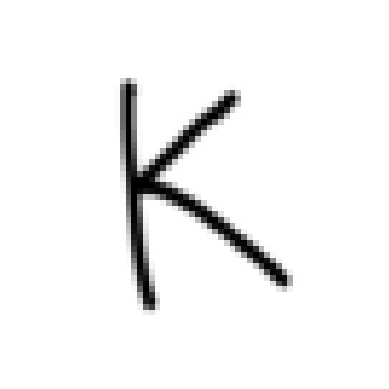

Predicted probabilities:
Class 0: 0.9999
Class 1: 0.0001
Class 2: 0.0000
Class 3: 0.0000
True Label: 0



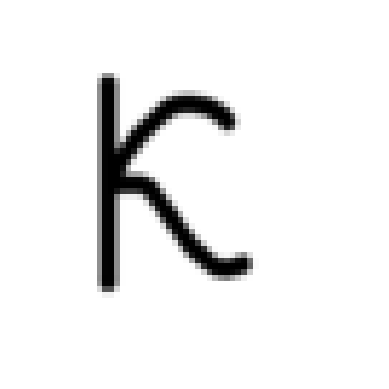

Predicted probabilities:
Class 0: 1.0000
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0000
True Label: 0



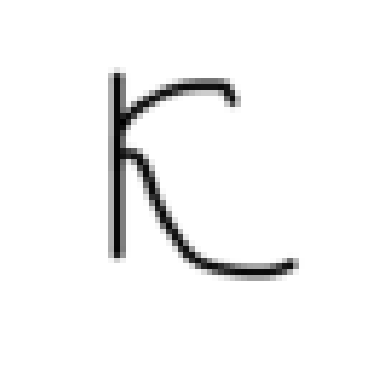

Predicted probabilities:
Class 0: 0.9982
Class 1: 0.0016
Class 2: 0.0001
Class 3: 0.0001
True Label: 0



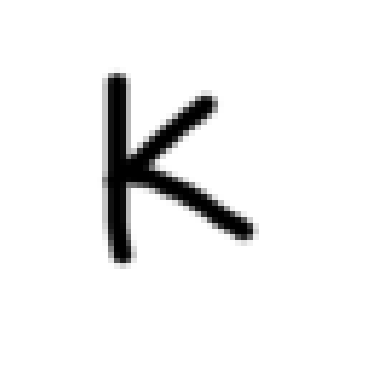

Predicted probabilities:
Class 0: 1.0000
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0000
True Label: 0



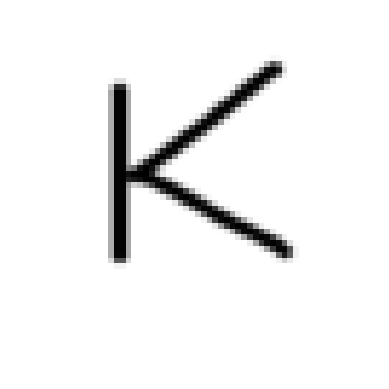

Predicted probabilities:
Class 0: 0.9985
Class 1: 0.0000
Class 2: 0.0014
Class 3: 0.0001
True Label: 0



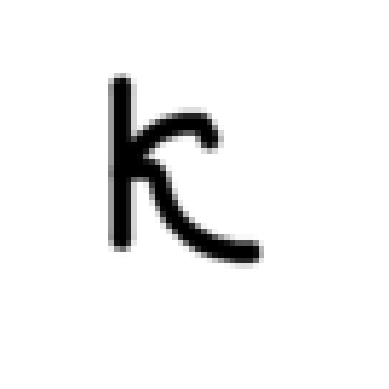

Predicted probabilities:
Class 0: 0.9949
Class 1: 0.0051
Class 2: 0.0000
Class 3: 0.0000
True Label: 0



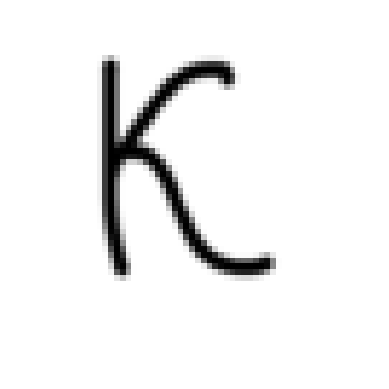

Predicted probabilities:
Class 0: 0.9939
Class 1: 0.0043
Class 2: 0.0000
Class 3: 0.0018
True Label: 0



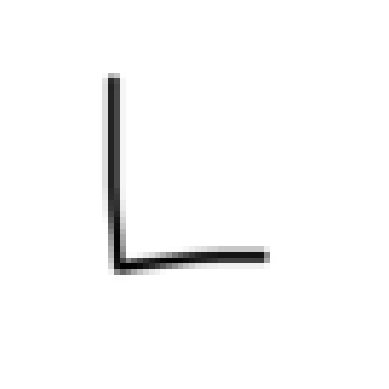

Predicted probabilities:
Class 0: 0.0041
Class 1: 0.9955
Class 2: 0.0000
Class 3: 0.0004
True Label: 1



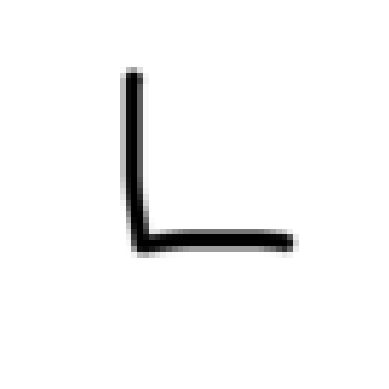

Predicted probabilities:
Class 0: 0.0162
Class 1: 0.9819
Class 2: 0.0001
Class 3: 0.0018
True Label: 1



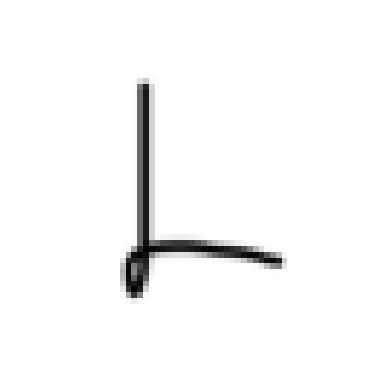

Predicted probabilities:
Class 0: 0.0035
Class 1: 0.9964
Class 2: 0.0000
Class 3: 0.0001
True Label: 1



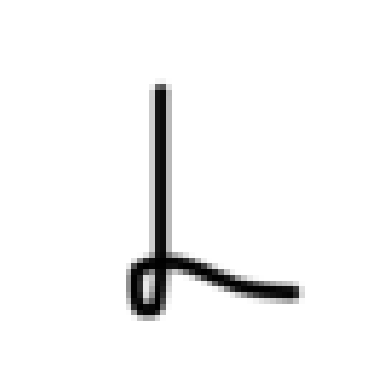

Predicted probabilities:
Class 0: 0.0000
Class 1: 1.0000
Class 2: 0.0000
Class 3: 0.0000
True Label: 1



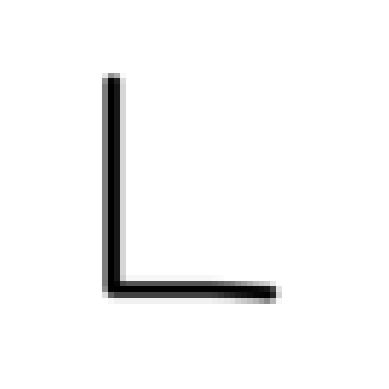

Predicted probabilities:
Class 0: 0.0351
Class 1: 0.9622
Class 2: 0.0000
Class 3: 0.0028
True Label: 1



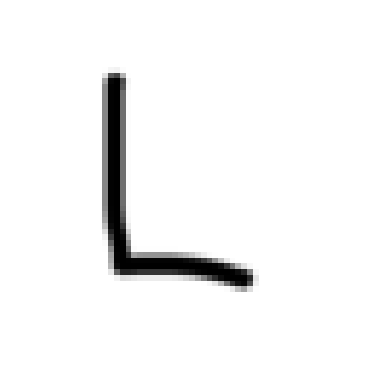

Predicted probabilities:
Class 0: 0.0008
Class 1: 0.9991
Class 2: 0.0000
Class 3: 0.0002
True Label: 1



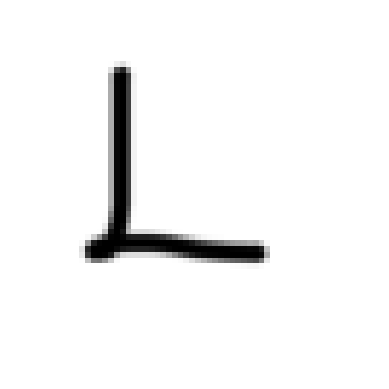

Predicted probabilities:
Class 0: 0.0203
Class 1: 0.9794
Class 2: 0.0000
Class 3: 0.0003
True Label: 1



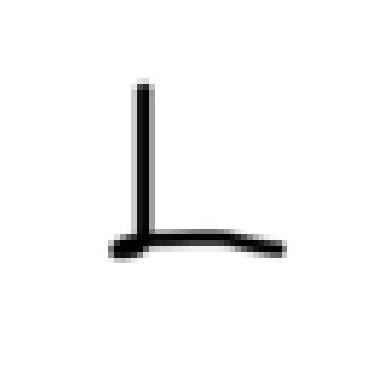

Predicted probabilities:
Class 0: 0.0078
Class 1: 0.9914
Class 2: 0.0000
Class 3: 0.0007
True Label: 1



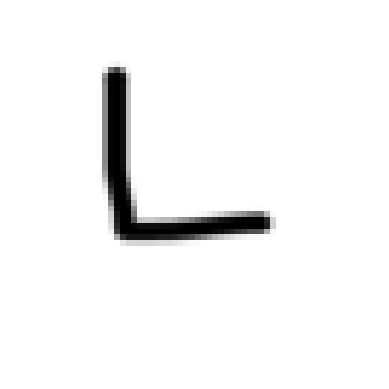

Predicted probabilities:
Class 0: 0.0725
Class 1: 0.8851
Class 2: 0.0002
Class 3: 0.0423
True Label: 1



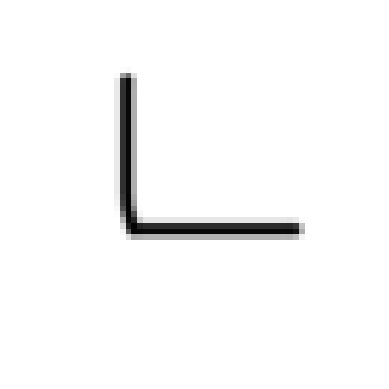

Predicted probabilities:
Class 0: 0.0768
Class 1: 0.7996
Class 2: 0.0087
Class 3: 0.1149
True Label: 1



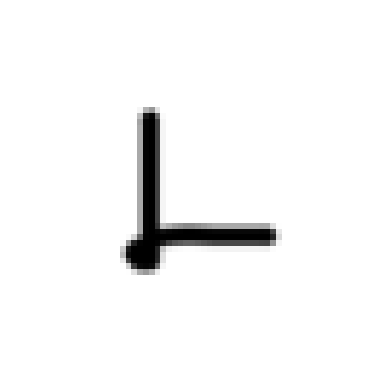

Predicted probabilities:
Class 0: 0.0002
Class 1: 0.9998
Class 2: 0.0000
Class 3: 0.0000
True Label: 1



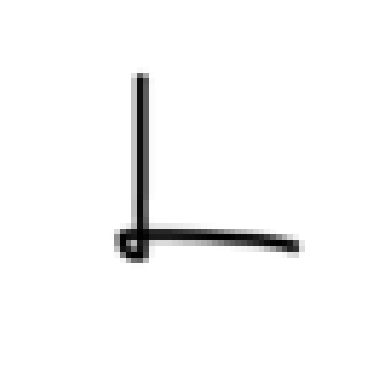

Predicted probabilities:
Class 0: 0.0133
Class 1: 0.9841
Class 2: 0.0003
Class 3: 0.0022
True Label: 1



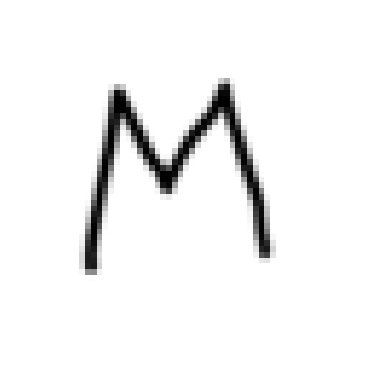

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.9999
Class 3: 0.0001
True Label: 2



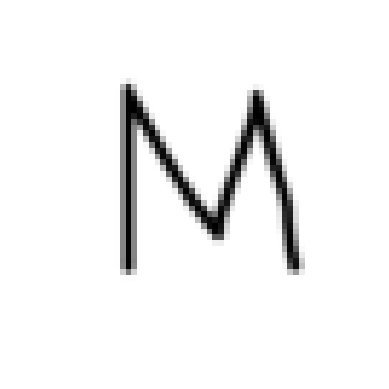

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.9997
Class 3: 0.0003
True Label: 2



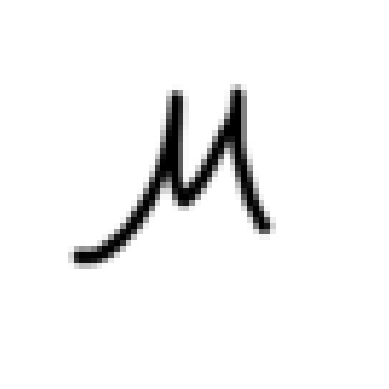

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



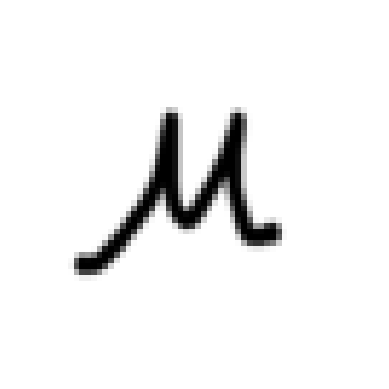

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



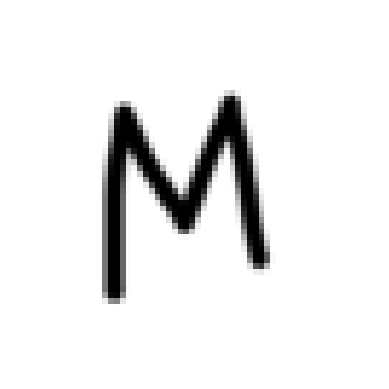

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



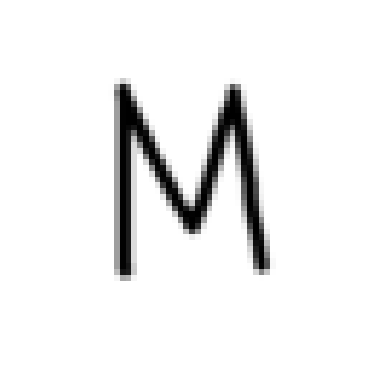

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



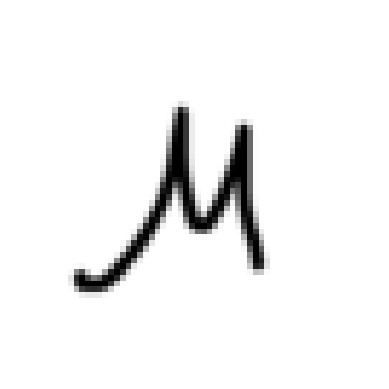

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.9995
Class 3: 0.0005
True Label: 2



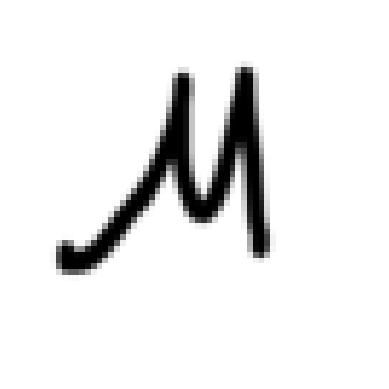

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



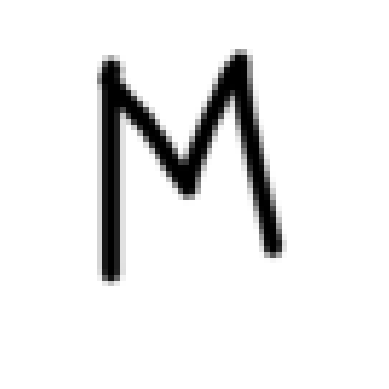

Predicted probabilities:
Class 0: 0.0001
Class 1: 0.0000
Class 2: 0.9959
Class 3: 0.0040
True Label: 2



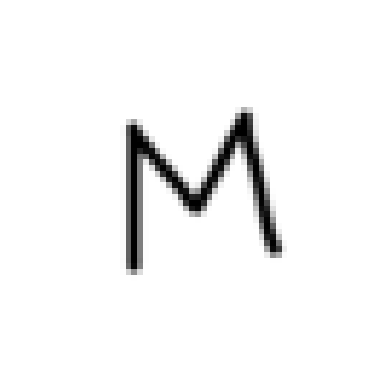

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



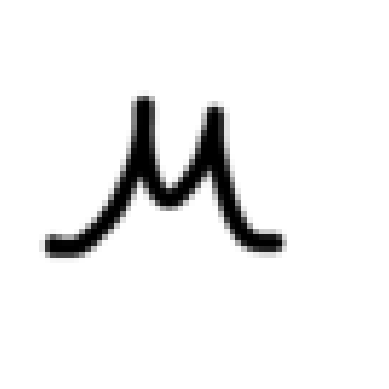

Predicted probabilities:
Class 0: 0.0001
Class 1: 0.0000
Class 2: 0.9999
Class 3: 0.0001
True Label: 2



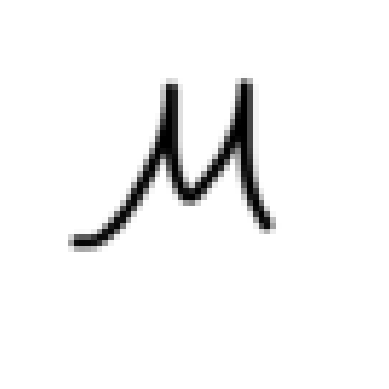

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
True Label: 2



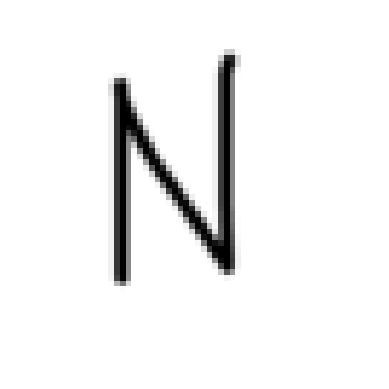

Predicted probabilities:
Class 0: 0.0042
Class 1: 0.0000
Class 2: 0.0099
Class 3: 0.9859
True Label: 3



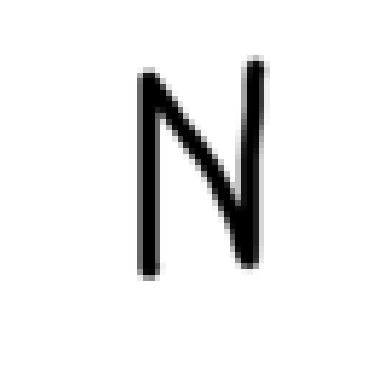

Predicted probabilities:
Class 0: 0.0002
Class 1: 0.0000
Class 2: 0.0201
Class 3: 0.9797
True Label: 3



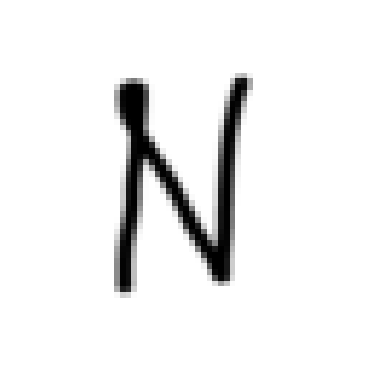

Predicted probabilities:
Class 0: 0.0007
Class 1: 0.0000
Class 2: 0.0029
Class 3: 0.9964
True Label: 3



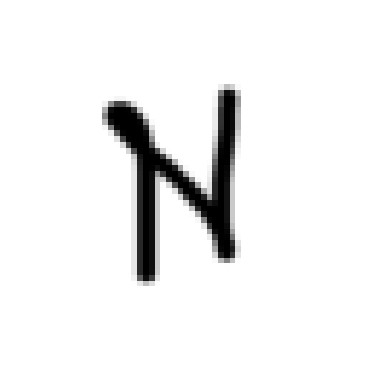

Predicted probabilities:
Class 0: 0.0212
Class 1: 0.0000
Class 2: 0.0006
Class 3: 0.9782
True Label: 3



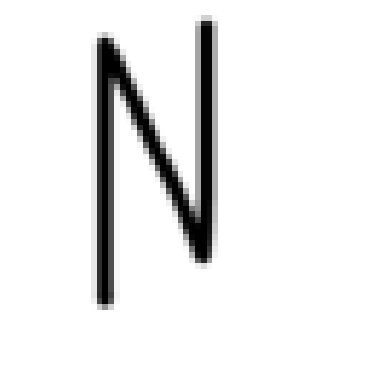

Predicted probabilities:
Class 0: 0.0017
Class 1: 0.0000
Class 2: 0.0022
Class 3: 0.9961
True Label: 3



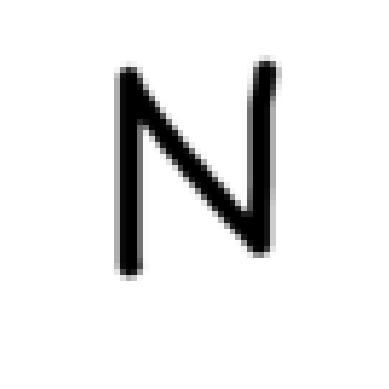

Predicted probabilities:
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.0007
Class 3: 0.9993
True Label: 3



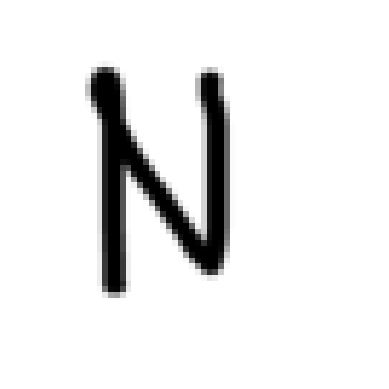

Predicted probabilities:
Class 0: 0.0116
Class 1: 0.0000
Class 2: 0.0011
Class 3: 0.9874
True Label: 3



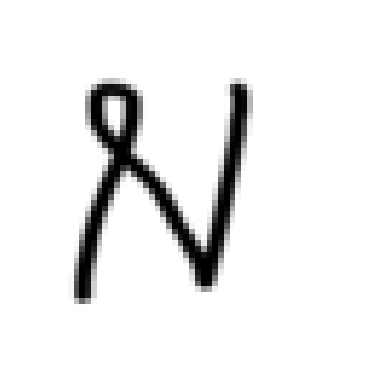

Predicted probabilities:
Class 0: 0.0002
Class 1: 0.0000
Class 2: 0.0055
Class 3: 0.9943
True Label: 3



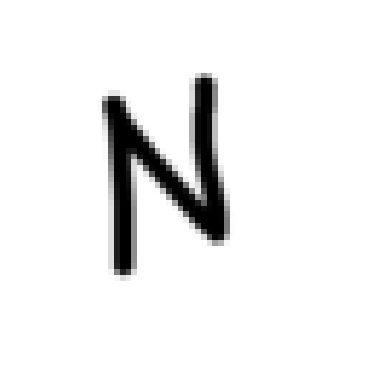

Predicted probabilities:
Class 0: 0.7537
Class 1: 0.0000
Class 2: 0.1905
Class 3: 0.0558
True Label: 3



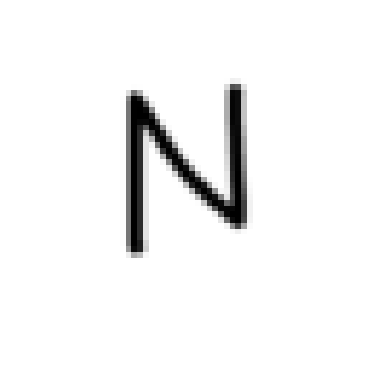

Predicted probabilities:
Class 0: 0.0039
Class 1: 0.0000
Class 2: 0.2373
Class 3: 0.7587
True Label: 3



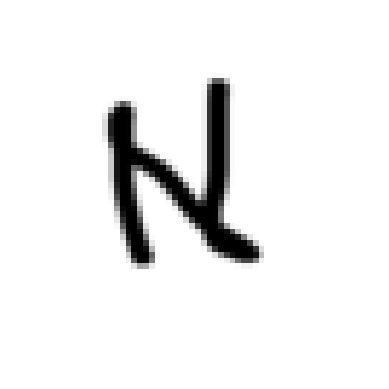

Predicted probabilities:
Class 0: 0.4538
Class 1: 0.0000
Class 2: 0.1671
Class 3: 0.3791
True Label: 3



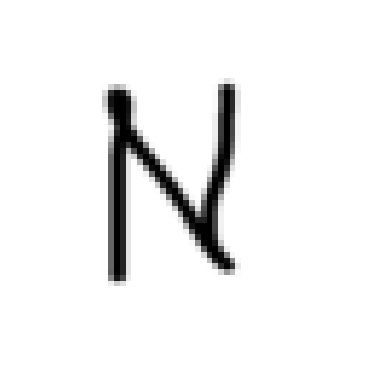

Predicted probabilities:
Class 0: 0.0012
Class 1: 0.0000
Class 2: 0.0020
Class 3: 0.9967
True Label: 3



In [ ]:

#с вероятностями
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(64*64, 128), # Входной слой
            nn.ReLU(),
            nn.Linear(128, 256), # Скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), # Выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), # Даёт вероятностное значение для каждой буквы
        )

    def forward(self, x):
        x = x.view(-1, 64*64)  # Преобразуем изображение в вектор
        return self._model(x)

# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                accuracy = correct / total * 100
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")
            iteration += 1

    return model

# Тестирование
def test_model(model):
    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),  # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)

    for inputs, label in test_dataset:
        inputs = inputs.unsqueeze(0)  # Добавляем размерность для батча
        outputs = model(inputs)

        # Преобразуем логарифмические вероятности в вероятности
        probabilities = torch.exp(outputs)

        # Визуализация изображения
        imshow(inputs.squeeze().cpu())
        print("Predicted probabilities:")
        for i, prob in enumerate(probabilities.squeeze()):
            print(f"Class {i}: {prob:.4f}")
        print(f"True Label: {label}\n")


model = train_model()
test_model(model)


Epoch 1/50, Loss: 1.3882
Epoch 1/50, Loss: 1.2484
Epoch 2/50, Loss: 1.1911
Epoch 2/50, Loss: 1.0754
Epoch 2/50, Loss: 1.0291
Epoch 3/50, Loss: 1.0767
Epoch 3/50, Loss: 0.8791
Epoch 4/50, Loss: 1.2272
Epoch 4/50, Loss: 0.7405
Epoch 4/50, Loss: 0.9850
Epoch 5/50, Loss: 0.8423
Epoch 5/50, Loss: 0.5738
Epoch 5/50, Loss: 0.9409
Epoch 6/50, Loss: 0.4071
Epoch 6/50, Loss: 0.6666
Epoch 7/50, Loss: 0.7575
Epoch 7/50, Loss: 0.5051
Epoch 7/50, Loss: 0.2570
Epoch 8/50, Loss: 0.7208
Epoch 8/50, Loss: 0.3640
Epoch 9/50, Loss: 0.4411
Epoch 9/50, Loss: 0.5433
Epoch 9/50, Loss: 0.2330
Epoch 10/50, Loss: 0.0873
Epoch 10/50, Loss: 0.4544
Epoch 10/50, Loss: 0.0567
Epoch 11/50, Loss: 0.5628
Epoch 11/50, Loss: 0.1847
Epoch 12/50, Loss: 0.2010
Epoch 12/50, Loss: 0.4670
Epoch 12/50, Loss: 0.8982
Epoch 13/50, Loss: 0.2000
Epoch 13/50, Loss: 0.1911
Epoch 14/50, Loss: 0.6124
Epoch 14/50, Loss: 0.1995
Epoch 14/50, Loss: 0.1087
Epoch 15/50, Loss: 0.0888
Epoch 15/50, Loss: 0.1483
Epoch 15/50, Loss: 0.2908
Epoch 16/

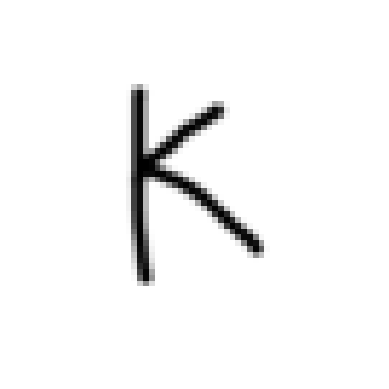

True Label: 0, Predicted: 0


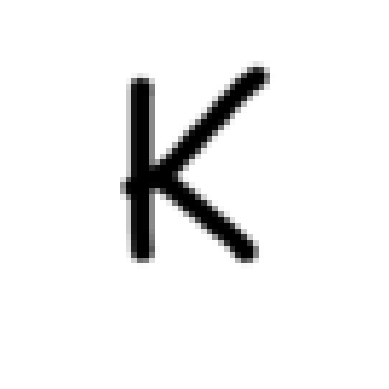

True Label: 0, Predicted: 0


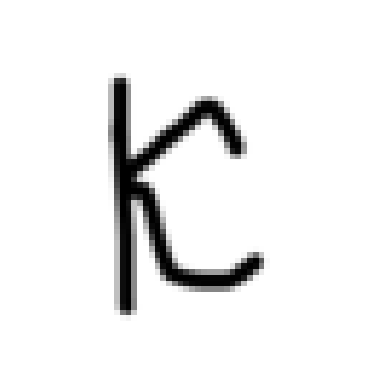

True Label: 0, Predicted: 0


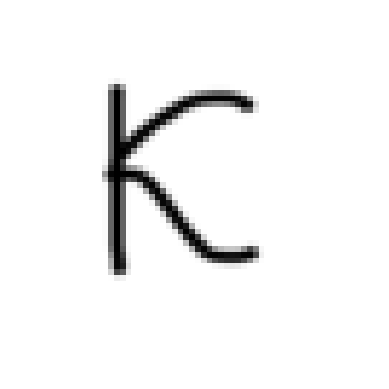

True Label: 0, Predicted: 0


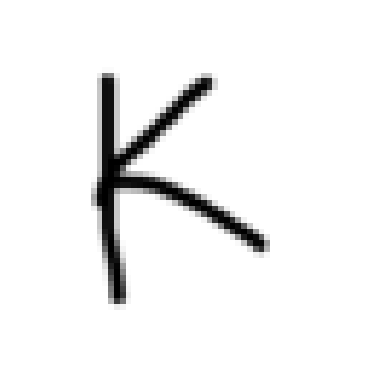

True Label: 0, Predicted: 0


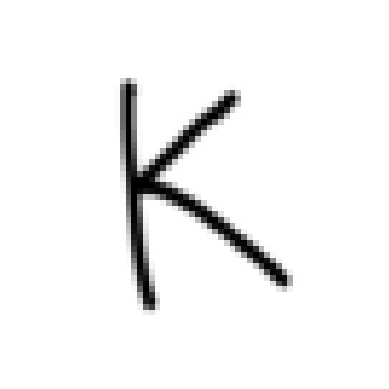

True Label: 0, Predicted: 0


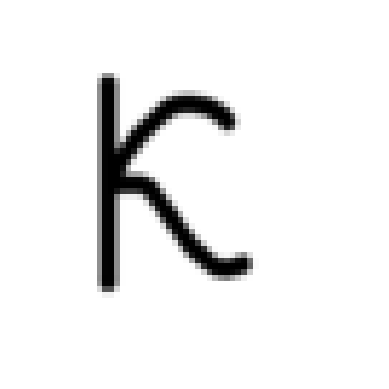

True Label: 0, Predicted: 0


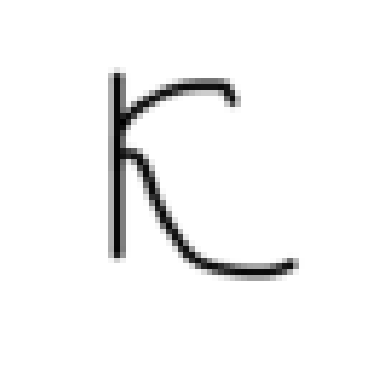

True Label: 0, Predicted: 0


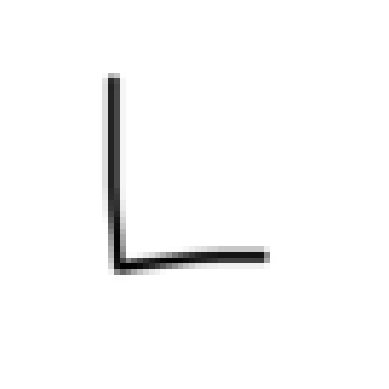

True Label: 1, Predicted: 1


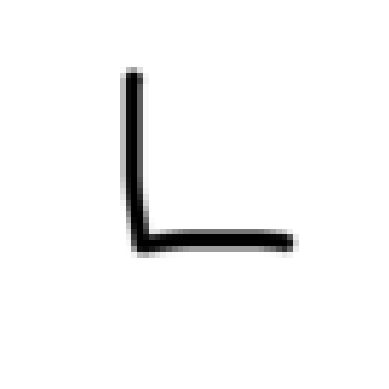

True Label: 1, Predicted: 1


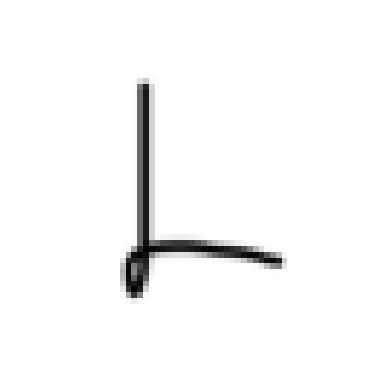

True Label: 1, Predicted: 1


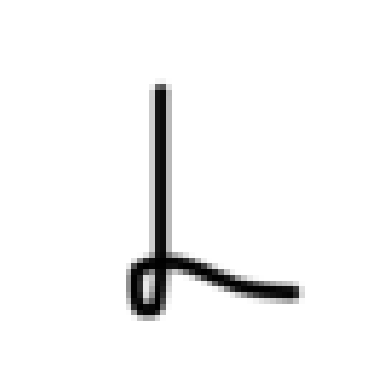

True Label: 1, Predicted: 1


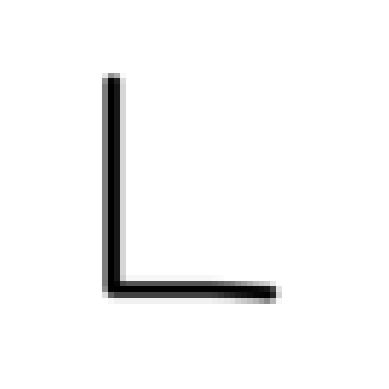

True Label: 1, Predicted: 1


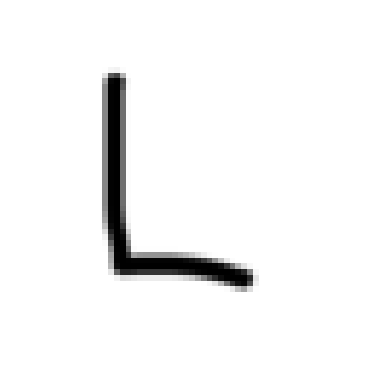

True Label: 1, Predicted: 1


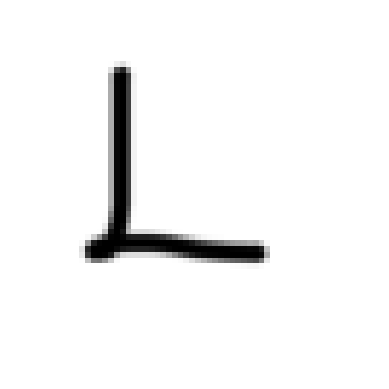

True Label: 1, Predicted: 1


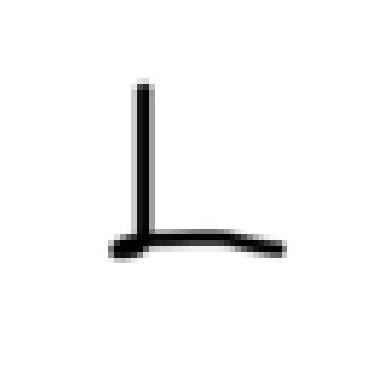

True Label: 1, Predicted: 1


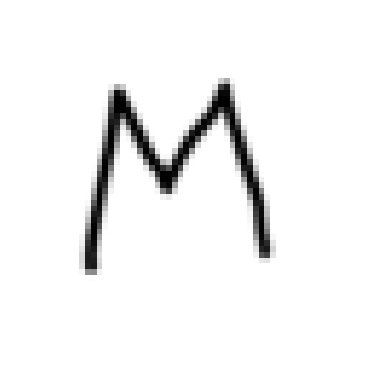

True Label: 2, Predicted: 2


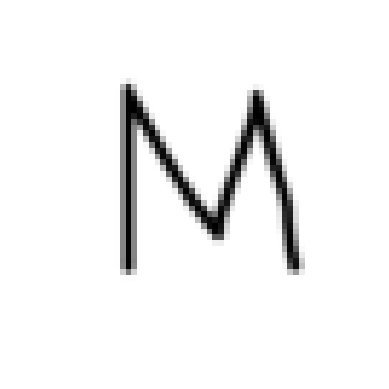

True Label: 2, Predicted: 2


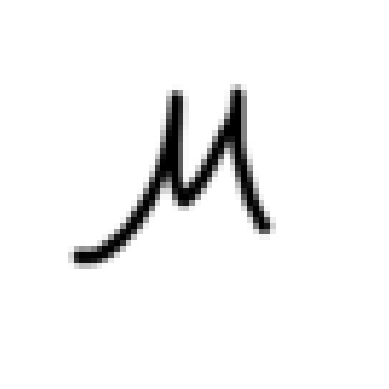

True Label: 2, Predicted: 2


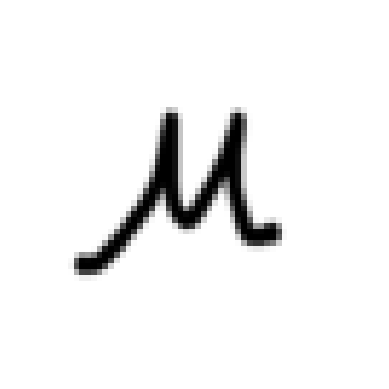

True Label: 2, Predicted: 2


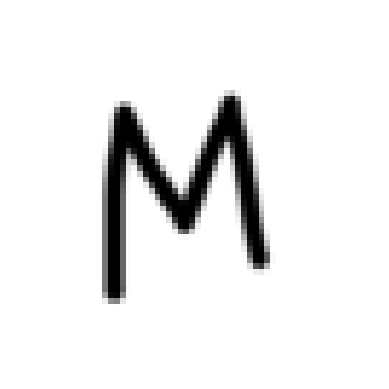

True Label: 2, Predicted: 2


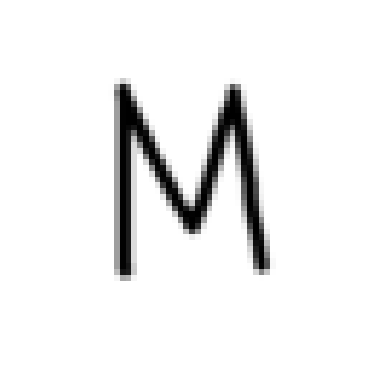

True Label: 2, Predicted: 2


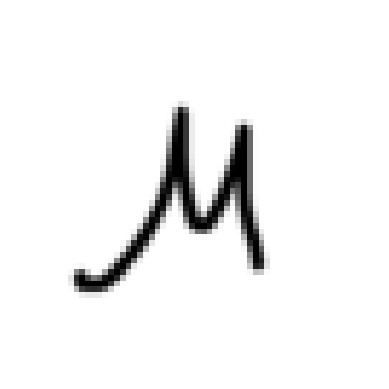

True Label: 2, Predicted: 2


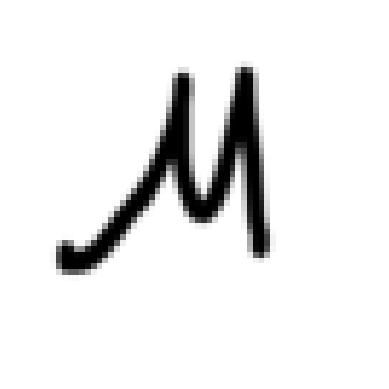

True Label: 2, Predicted: 2


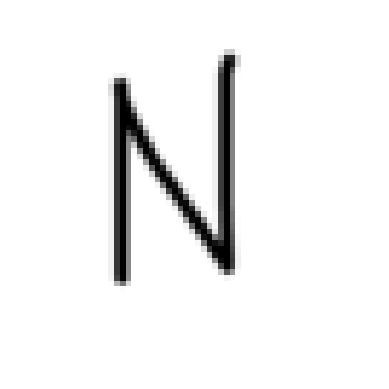

True Label: 3, Predicted: 3


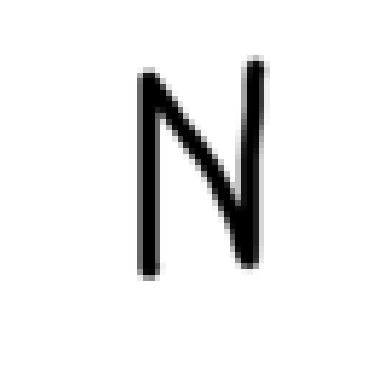

True Label: 3, Predicted: 3


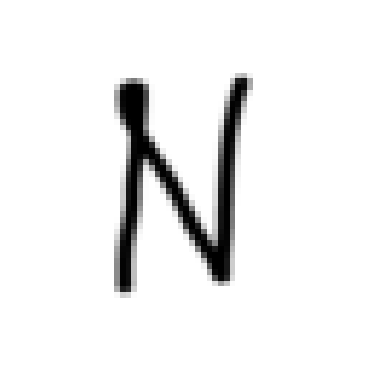

True Label: 3, Predicted: 3


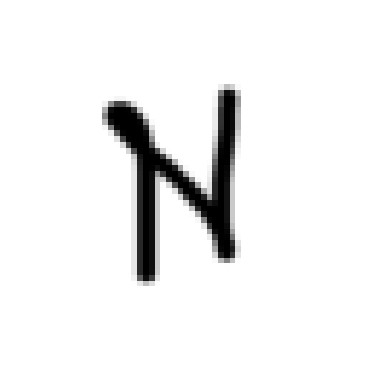

True Label: 3, Predicted: 3


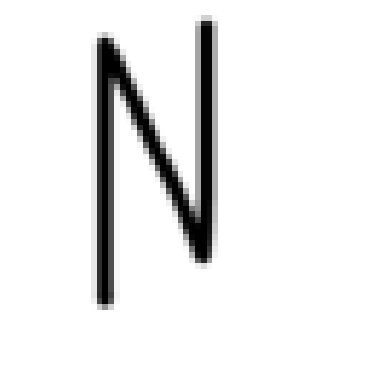

True Label: 3, Predicted: 3


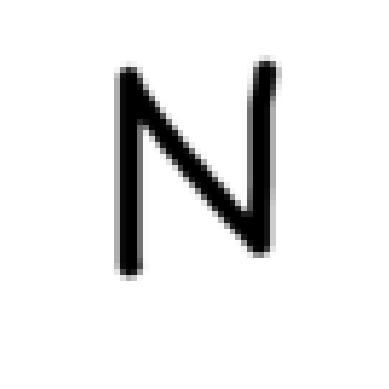

True Label: 3, Predicted: 3


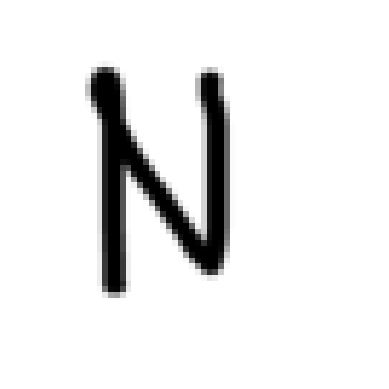

True Label: 3, Predicted: 3


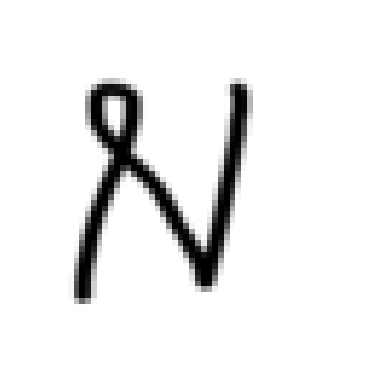

True Label: 3, Predicted: 3
Accuracy: 100.00%


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(64*64, 128), # Входной слой
            nn.ReLU(),
            nn.Linear(128, 256), # Скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), # Выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), # Даёт вероятностное значение для каждой буквы
        )

    def forward(self, x):
        x = x.view(-1, 64*64)  # Преобразуем изображение в вектор
        return self._model(x)

# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
            iteration += 1

    return model

# Тестирование
def test_model(model):

    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    correct = 0
    total = 0

    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        correct += (predicted.item() == label)
        total += 1
        imshow(inputs.cpu())
        print(f"True Label: {label}, Predicted: {predicted.item()}")

    accuracy = correct / total * 100
    print(f"Accuracy: {accuracy:.2f}%")

model = train_model()
test_model(model)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(64*64, 128), # Входной слой
            nn.ReLU(),
            nn.Linear(128, 256), # Скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), # Выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), # Даёт вероятностное значение для каждой буквы
        )

    def forward(self, x):
        x = x.view(-1, 64*64)  # Преобразуем изображение в вектор
        return self._model(x)

# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                accuracy = correct / total * 100
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")
            iteration += 1

    return model

# Тестирование
def test_model(model):

    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    correct = 0
    total = 0

    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        correct += (predicted.item() == label)
        total += 1
        imshow(inputs.cpu())
        print(f"True Label: {label}, Predicted: {predicted.item()}")



model = train_model()
test_model(model)


Epoch 1/50, Loss: 1.4877, Accuracy: 35.00%
Epoch 1/50, Loss: 1.2253, Accuracy: 35.00%
Epoch 2/50, Loss: 1.4053, Accuracy: 25.00%
Epoch 2/50, Loss: 1.1718, Accuracy: 39.29%
Epoch 2/50, Loss: 1.0982, Accuracy: 48.33%
Epoch 3/50, Loss: 0.8892, Accuracy: 50.00%
Epoch 3/50, Loss: 1.0783, Accuracy: 51.67%


KeyboardInterrupt: 

Epoch 1/50, Loss: 1.2130, Accuracy: 29.00%
Epoch 1/50, Loss: 1.5942, Accuracy: 30.50%
Epoch 2/50, Loss: 1.1347, Accuracy: 45.00%
Epoch 2/50, Loss: 1.3454, Accuracy: 38.57%
Epoch 2/50, Loss: 0.8746, Accuracy: 48.33%
Epoch 3/50, Loss: 1.0107, Accuracy: 57.50%
Epoch 3/50, Loss: 1.0644, Accuracy: 59.44%
Epoch 4/50, Loss: 0.5742, Accuracy: 70.00%
Epoch 4/50, Loss: 0.6125, Accuracy: 65.83%
Epoch 4/50, Loss: 0.9095, Accuracy: 65.45%
Epoch 5/50, Loss: 0.5762, Accuracy: 73.33%
Epoch 5/50, Loss: 0.4535, Accuracy: 71.88%
Epoch 5/50, Loss: 1.3554, Accuracy: 70.75%
Epoch 6/50, Loss: 0.6496, Accuracy: 81.00%
Epoch 6/50, Loss: 0.8238, Accuracy: 75.50%
Epoch 7/50, Loss: 0.4886, Accuracy: 85.00%
Epoch 7/50, Loss: 0.3146, Accuracy: 81.43%
Epoch 7/50, Loss: 0.7079, Accuracy: 79.58%
Epoch 8/50, Loss: 0.4218, Accuracy: 83.75%
Epoch 8/50, Loss: 0.5430, Accuracy: 84.44%
Epoch 9/50, Loss: 0.6783, Accuracy: 75.00%
Epoch 9/50, Loss: 0.4441, Accuracy: 83.33%
Epoch 9/50, Loss: 0.4797, Accuracy: 85.00%
Epoch 10/50

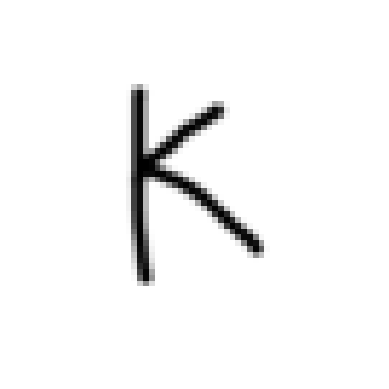

True Label: 0, Predicted: 0


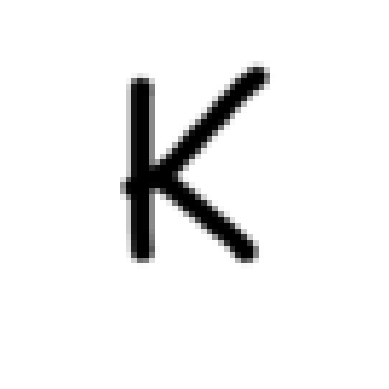

True Label: 0, Predicted: 0


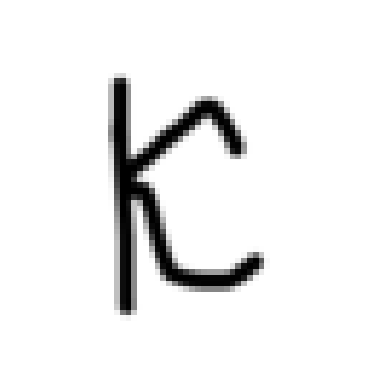

True Label: 0, Predicted: 0


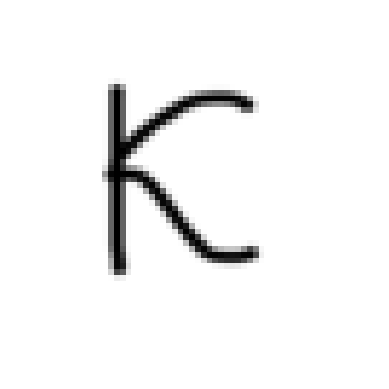

True Label: 0, Predicted: 0


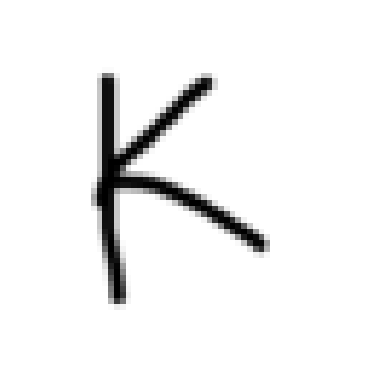

True Label: 0, Predicted: 0


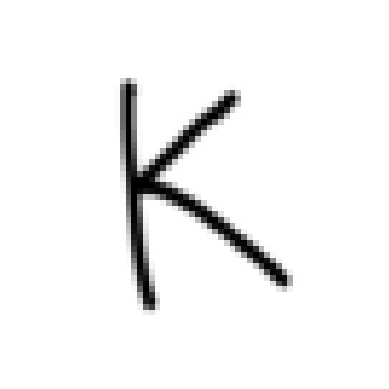

True Label: 0, Predicted: 0


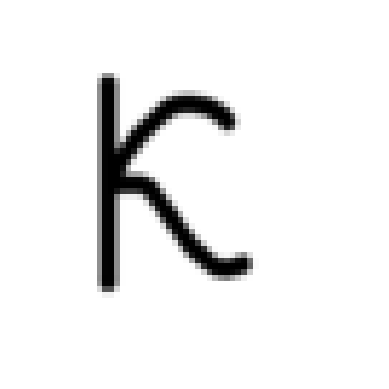

True Label: 0, Predicted: 0


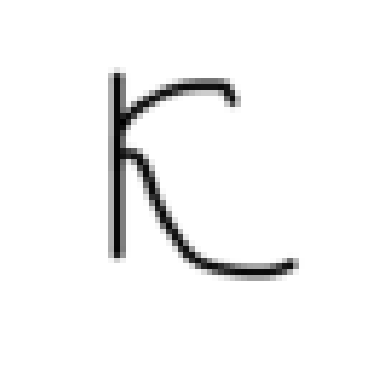

True Label: 0, Predicted: 0


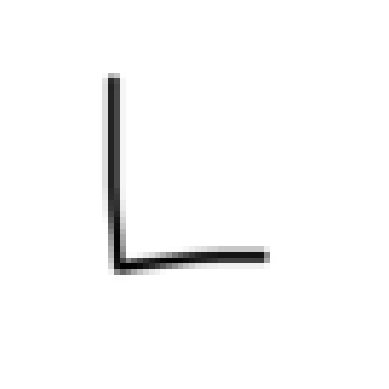

True Label: 1, Predicted: 1


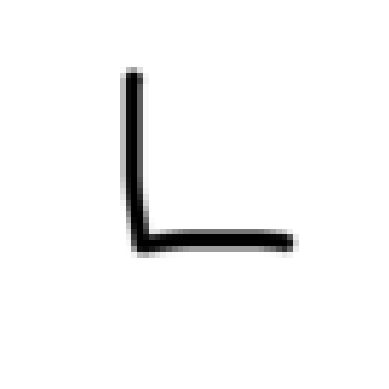

True Label: 1, Predicted: 1


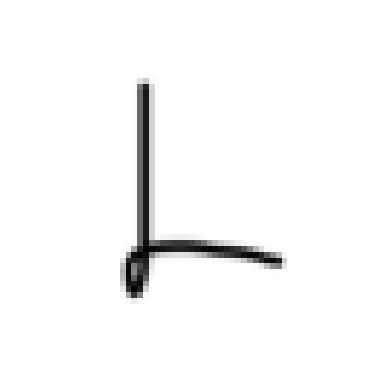

True Label: 1, Predicted: 1


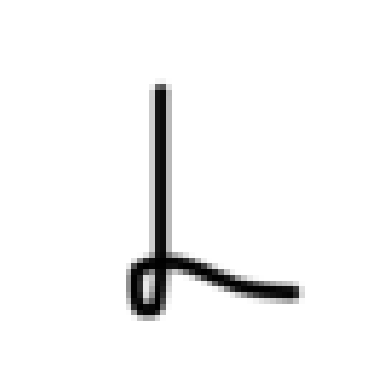

True Label: 1, Predicted: 1


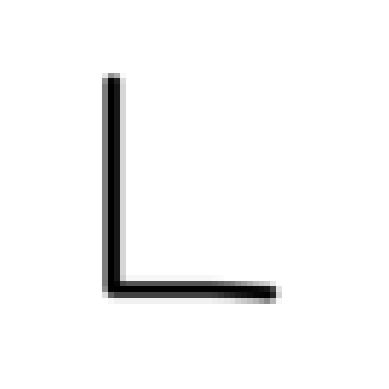

True Label: 1, Predicted: 1


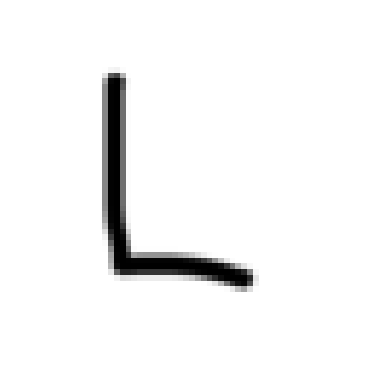

True Label: 1, Predicted: 1


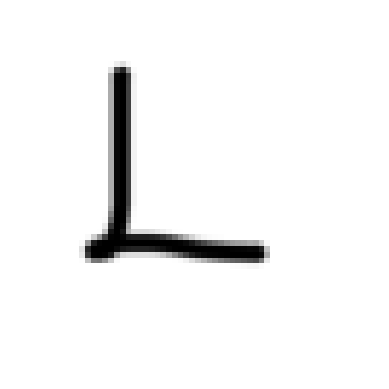

True Label: 1, Predicted: 1


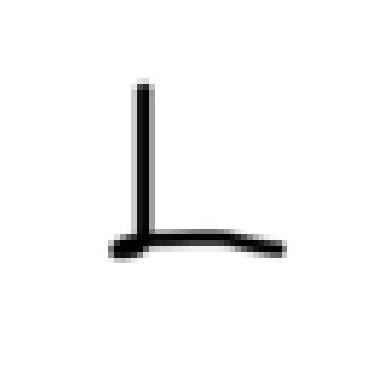

True Label: 1, Predicted: 1


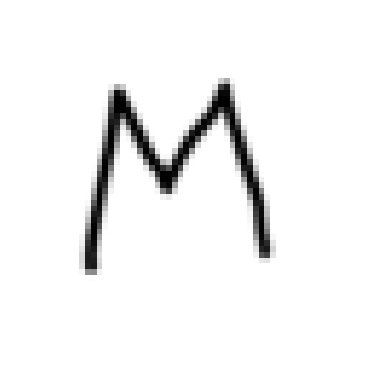

True Label: 2, Predicted: 2


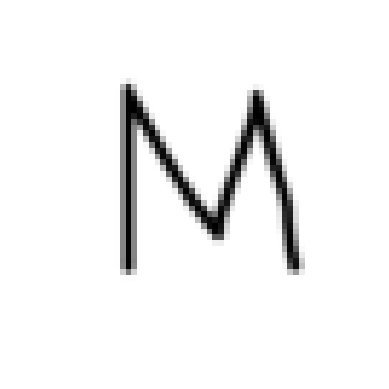

True Label: 2, Predicted: 2


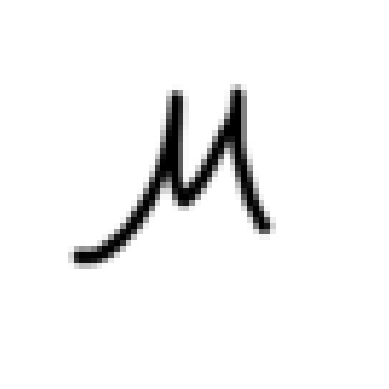

True Label: 2, Predicted: 2


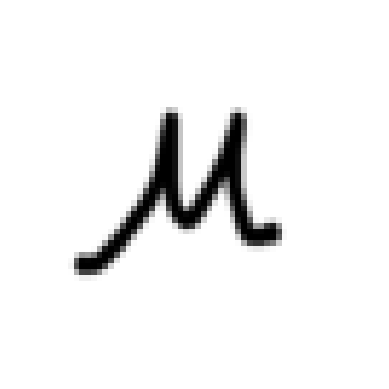

True Label: 2, Predicted: 2


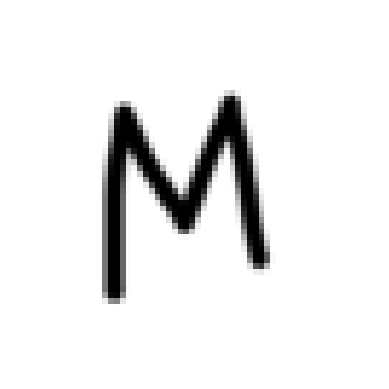

True Label: 2, Predicted: 2


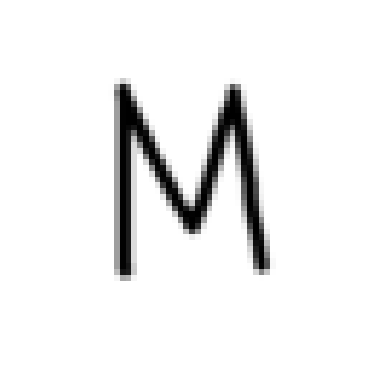

True Label: 2, Predicted: 2


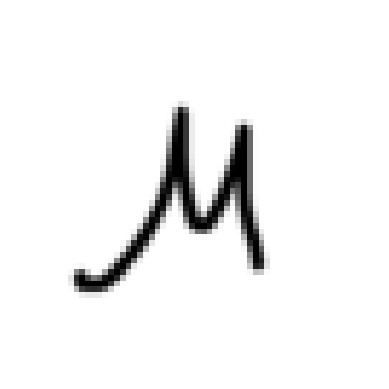

True Label: 2, Predicted: 2


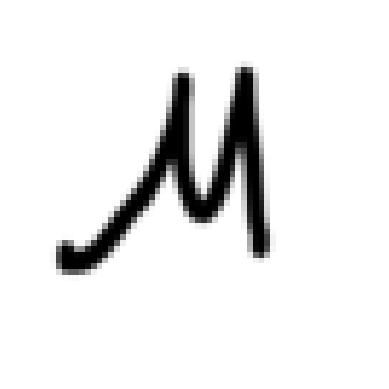

True Label: 2, Predicted: 2


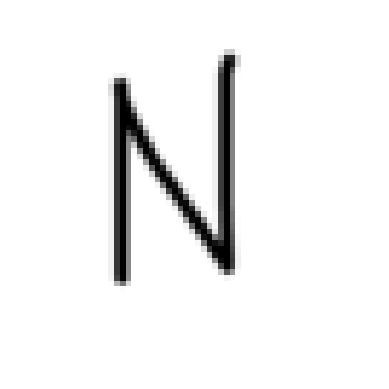

True Label: 3, Predicted: 3


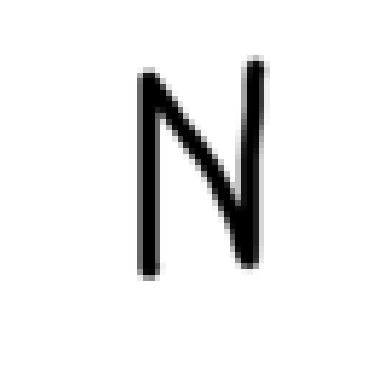

True Label: 3, Predicted: 3


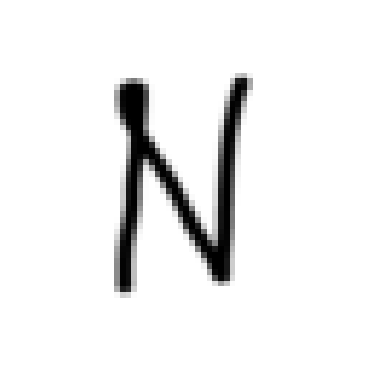

True Label: 3, Predicted: 3


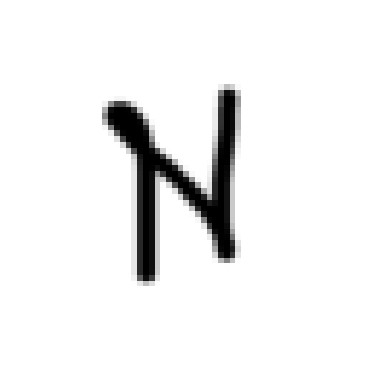

True Label: 3, Predicted: 3


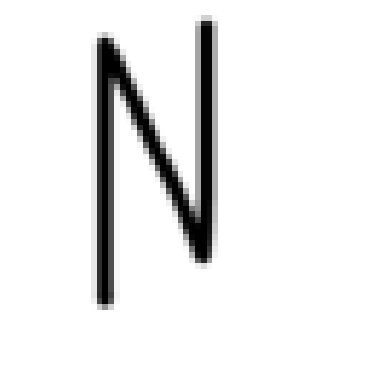

True Label: 3, Predicted: 3


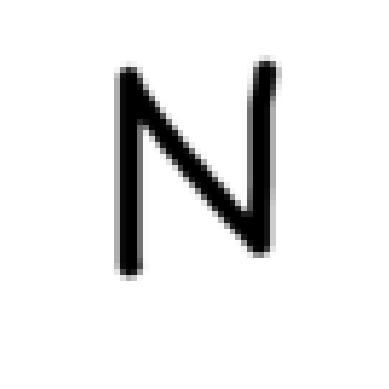

True Label: 3, Predicted: 3


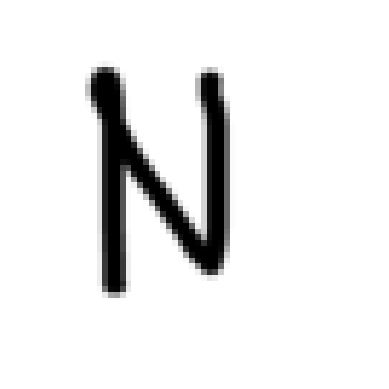

True Label: 3, Predicted: 3


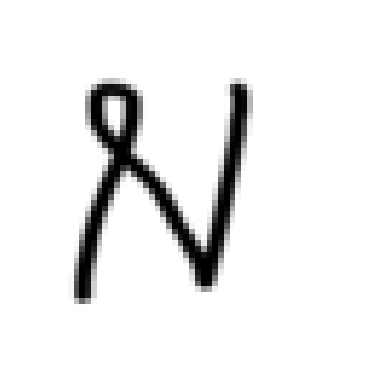

True Label: 3, Predicted: 3
Accuracy: 100.00%


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(64*64, 128), # Входной слой
            nn.ReLU(),
            nn.Linear(128, 256), # Скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), # Выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), # Даёт вероятностное значение для каждой буквы
        )

    def forward(self, x):
        x = x.view(-1, 64*64)  # Преобразуем изображение в вектор
        return self._model(x)

# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                accuracy = correct / total * 100
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")
            iteration += 1

    return model

# Тестирование
def test_model(model):

    root_dir = "/content/drive/MyDrive/dataset_test"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)
    correct = 0
    total = 0

    for inputs, label in test_dataset:
        outputs = model(inputs.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        correct += (predicted.item() == label)
        total += 1
        imshow(inputs.cpu())
        print(f"True Label: {label}, Predicted: {predicted.item()}")

    accuracy = correct / total * 100
    print(f"Accuracy: {accuracy:.2f}%")

model = train_model()
test_model(model)


In [ ]:
# Тестирование
def test_model(model):
    root_dir = "/content/drive/MyDrive/dataset_test"

    # Отображение индексов классов в буквы
    class_names = {0: "K", 1: "L", 2: "M", 3: "N"}

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),  # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)

    for inputs, label in test_dataset:
        inputs = inputs.unsqueeze(0)  # Добавляем размерность для батча
        outputs = model(inputs)

        # Преобразуем логарифмические вероятности в вероятности
        probabilities = torch.exp(outputs)

        # Визуализация изображения
        imshow(inputs.squeeze().cpu())
        print("Predicted probabilities:")
        for i, prob in enumerate(probabilities.squeeze()):
            print(f"{class_names[i]}: {prob:.4f}")
        print(f"True Label: {class_names[label]}\n")


Epoch 1/50, Loss: 1.0747, Accuracy: 25.00%
Epoch 1/50, Loss: 1.1806, Accuracy: 30.00%
Epoch 2/50, Loss: 1.2038, Accuracy: 52.00%
Epoch 2/50, Loss: 1.1470, Accuracy: 44.00%
Epoch 2/50, Loss: 1.2061, Accuracy: 44.58%
Epoch 3/50, Loss: 0.8832, Accuracy: 44.00%
Epoch 3/50, Loss: 1.0634, Accuracy: 45.00%
Epoch 4/50, Loss: 0.9597, Accuracy: 66.00%
Epoch 4/50, Loss: 0.7900, Accuracy: 61.33%
Epoch 4/50, Loss: 0.9759, Accuracy: 63.45%
Epoch 5/50, Loss: 0.9293, Accuracy: 66.00%
Epoch 5/50, Loss: 1.0768, Accuracy: 63.50%
Epoch 6/50, Loss: 0.6385, Accuracy: 60.00%
Epoch 6/50, Loss: 0.9123, Accuracy: 68.00%
Epoch 6/50, Loss: 0.9455, Accuracy: 67.87%
Epoch 7/50, Loss: 0.4863, Accuracy: 73.00%
Epoch 7/50, Loss: 0.3482, Accuracy: 77.50%
Epoch 8/50, Loss: 0.3487, Accuracy: 86.00%
Epoch 8/50, Loss: 0.1811, Accuracy: 76.67%
Epoch 8/50, Loss: 0.6875, Accuracy: 74.70%
Epoch 9/50, Loss: 0.3321, Accuracy: 76.00%
Epoch 9/50, Loss: 0.3802, Accuracy: 77.00%
Epoch 10/50, Loss: 0.3915, Accuracy: 82.00%
Epoch 10/5

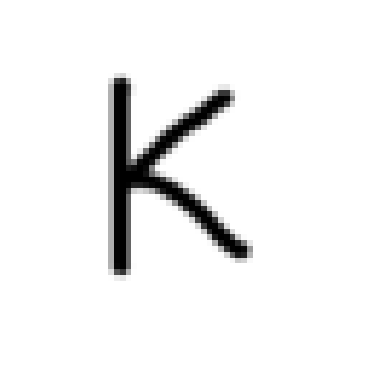

Predicted probabilities:
K: 0.9907
L: 0.0003
M: 0.0000
N: 0.0090
True Label: K
Predicted Label: K



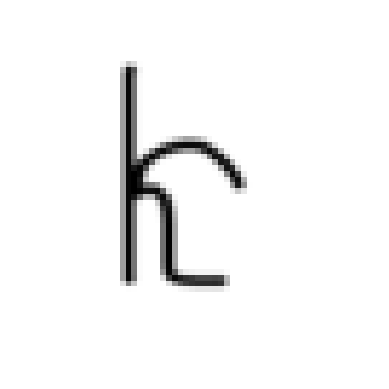

Predicted probabilities:
K: 0.0192
L: 0.1428
M: 0.0192
N: 0.8188
True Label: K
Predicted Label: N



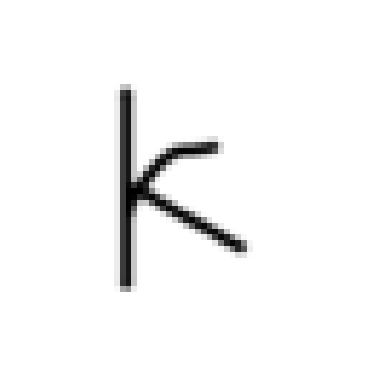

Predicted probabilities:
K: 0.1551
L: 0.6800
M: 0.0009
N: 0.1639
True Label: K
Predicted Label: L



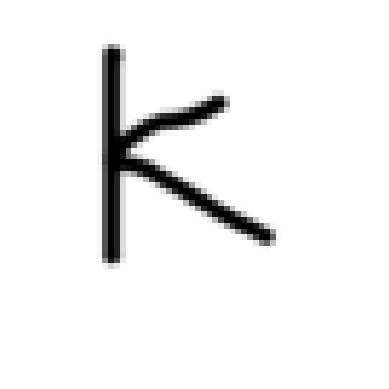

Predicted probabilities:
K: 0.9287
L: 0.0004
M: 0.0001
N: 0.0708
True Label: K
Predicted Label: K



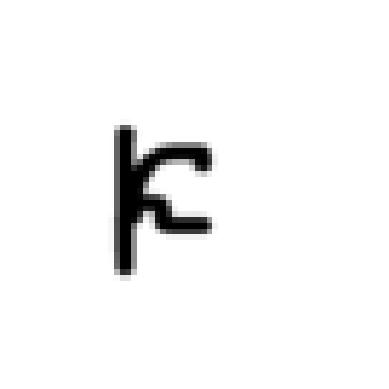

Predicted probabilities:
K: 0.9745
L: 0.0180
M: 0.0041
N: 0.0034
True Label: K
Predicted Label: K



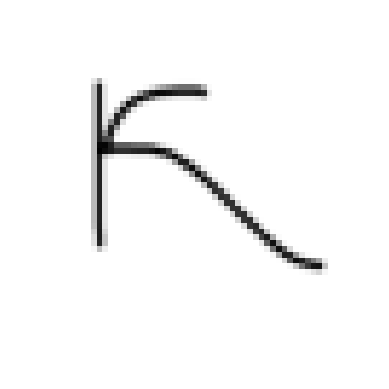

Predicted probabilities:
K: 0.0001
L: 0.0001
M: 0.0090
N: 0.9908
True Label: K
Predicted Label: N



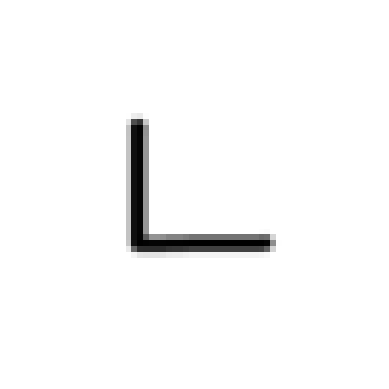

Predicted probabilities:
K: 0.0060
L: 0.5184
M: 0.0003
N: 0.4753
True Label: L
Predicted Label: L



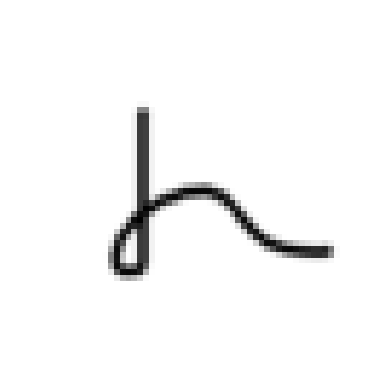

Predicted probabilities:
K: 0.0163
L: 0.6672
M: 0.0045
N: 0.3119
True Label: L
Predicted Label: L



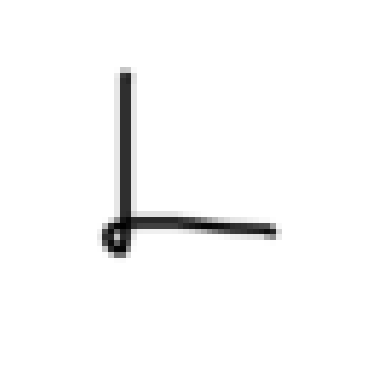

Predicted probabilities:
K: 0.0028
L: 0.7435
M: 0.0009
N: 0.2528
True Label: L
Predicted Label: L



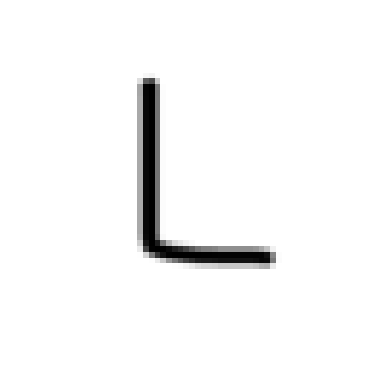

Predicted probabilities:
K: 0.0001
L: 0.9990
M: 0.0000
N: 0.0009
True Label: L
Predicted Label: L



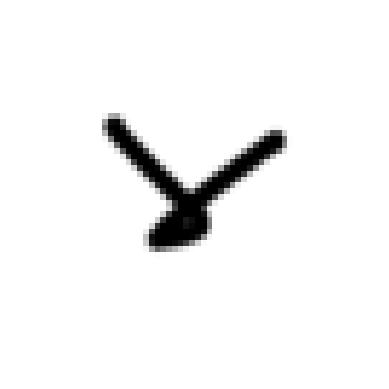

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.5621
N: 0.4379
True Label: L
Predicted Label: M



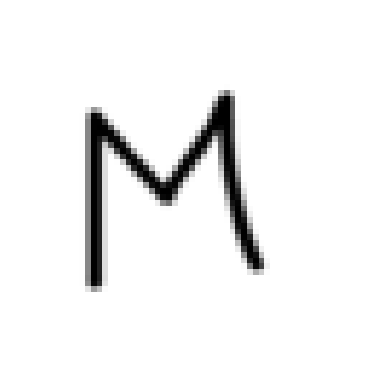

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9996
N: 0.0003
True Label: M
Predicted Label: M



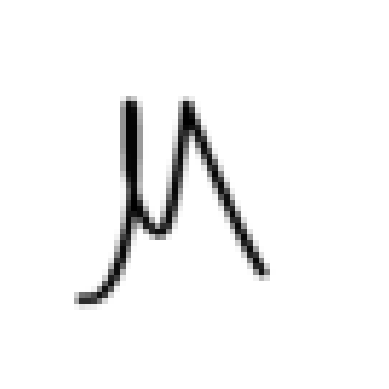

Predicted probabilities:
K: 0.6978
L: 0.0023
M: 0.1289
N: 0.1710
True Label: M
Predicted Label: K



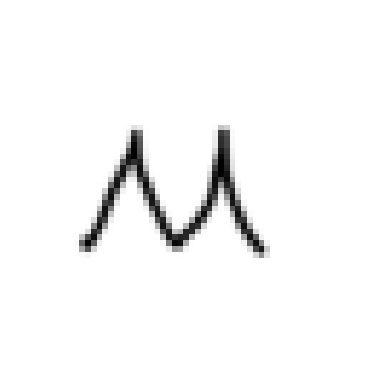

Predicted probabilities:
K: 0.0002
L: 0.0000
M: 0.1878
N: 0.8119
True Label: M
Predicted Label: N



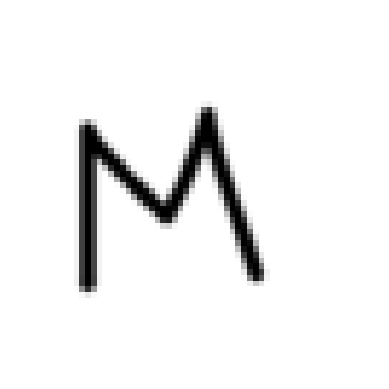

Predicted probabilities:
K: 0.0008
L: 0.0000
M: 0.9951
N: 0.0041
True Label: M
Predicted Label: M



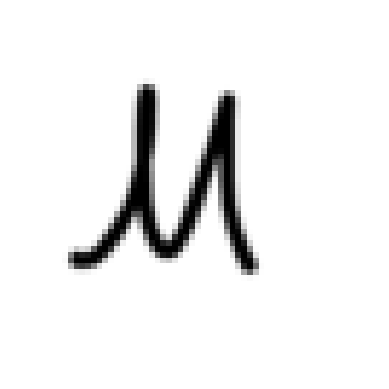

Predicted probabilities:
K: 0.0001
L: 0.0000
M: 0.8938
N: 0.1060
True Label: M
Predicted Label: M



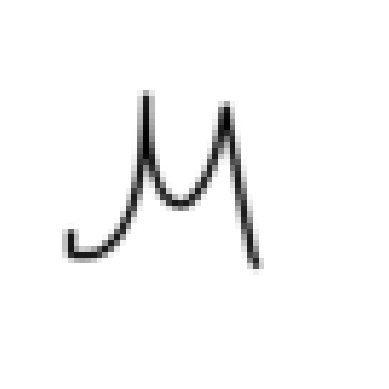

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9184
N: 0.0815
True Label: M
Predicted Label: M



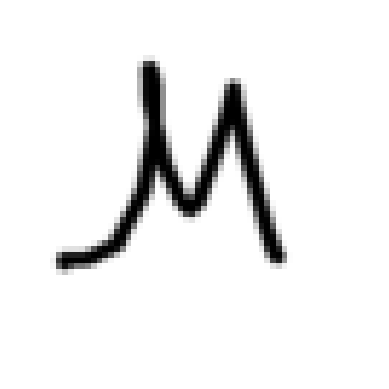

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9999
N: 0.0001
True Label: M
Predicted Label: M



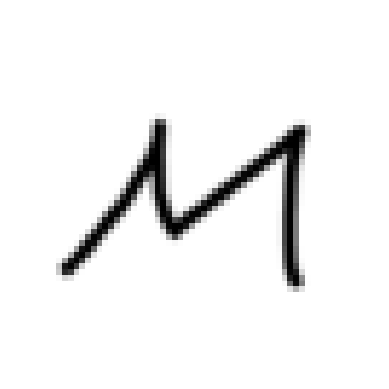

Predicted probabilities:
K: 0.0001
L: 0.0000
M: 0.9799
N: 0.0200
True Label: M
Predicted Label: M



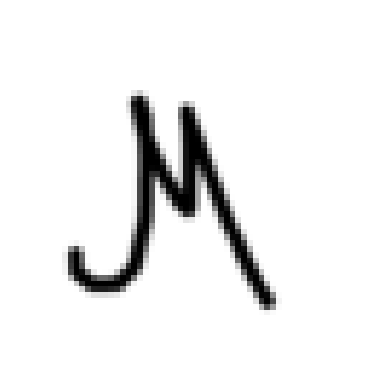

Predicted probabilities:
K: 0.9965
L: 0.0001
M: 0.0002
N: 0.0031
True Label: M
Predicted Label: K



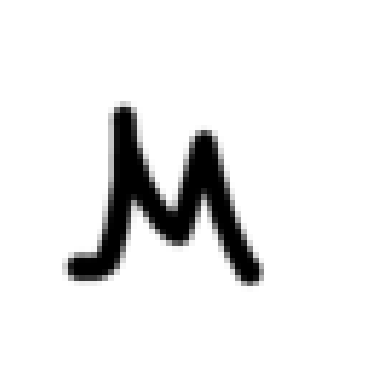

Predicted probabilities:
K: 0.6460
L: 0.0000
M: 0.2889
N: 0.0651
True Label: M
Predicted Label: K



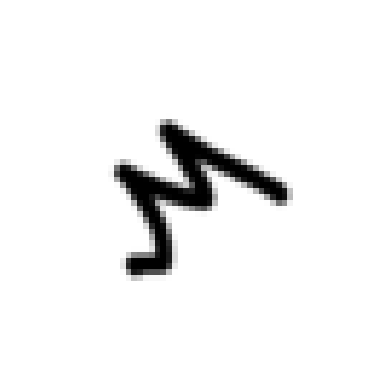

Predicted probabilities:
K: 0.0009
L: 0.0000
M: 0.6806
N: 0.3185
True Label: M
Predicted Label: M



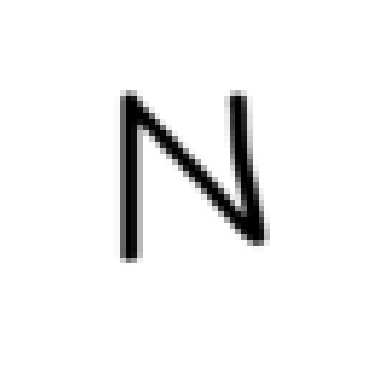

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0165
N: 0.9835
True Label: N
Predicted Label: N



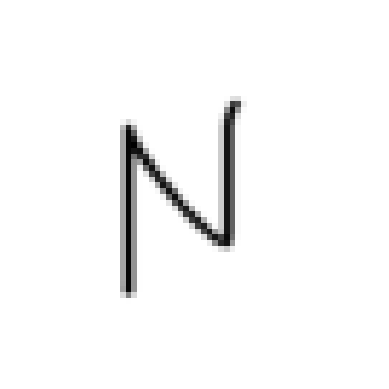

Predicted probabilities:
K: 0.0008
L: 0.0011
M: 0.0107
N: 0.9874
True Label: N
Predicted Label: N



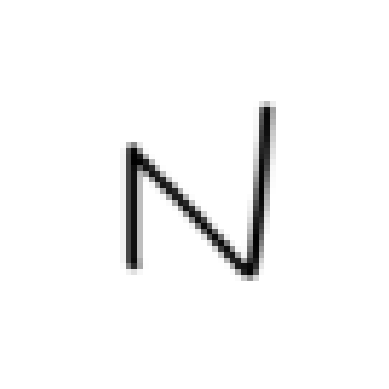

Predicted probabilities:
K: 0.0004
L: 0.0001
M: 0.0316
N: 0.9680
True Label: N
Predicted Label: N



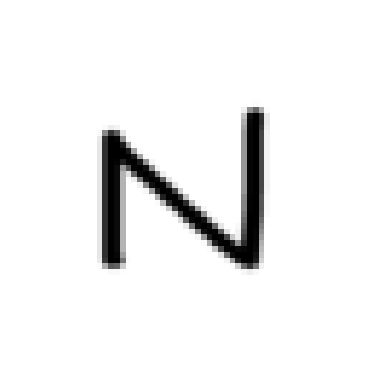

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0261
N: 0.9739
True Label: N
Predicted Label: N



In [ ]:

#с вероятностями
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self._model = nn.Sequential(
            nn.Linear(64*64, 128), # Входной слой
            nn.ReLU(),
            nn.Linear(128, 256), # Скрытый слой
            nn.ReLU(),
            nn.Linear(256, 4), # Выходной слой (4 нейрона - 4 буквы)
            nn.LogSoftmax(), # Даёт вероятностное значение для каждой буквы
        )

    def forward(self, x):
        x = x.view(-1, 64*64)  # Преобразуем изображение в вектор
        return self._model(x)

# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                accuracy = correct / total * 100
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")
            iteration += 1

    return model

# Тестирование
def test_model(model):
    root_dir = "/content/drive/MyDrive/dataset_test"

    # Отображение индексов классов в буквы
    class_names = {0: "K", 1: "L", 2: "M", 3: "N"}

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),  # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)

    for inputs, label in test_dataset:
        inputs = inputs.unsqueeze(0)  # Добавляем размерность для батча
        outputs = model(inputs)

        # Преобразуем логарифмические вероятности в вероятности
        probabilities = torch.exp(outputs)

        # Определяем индекс и название класса с максимальной вероятностью
        predicted_index = torch.argmax(probabilities, dim=1).item()
        predicted_label = class_names[predicted_index]

        # Визуализация изображения
        imshow(inputs.squeeze().cpu())
        print("Predicted probabilities:")
        for i, prob in enumerate(probabilities.squeeze()):
            print(f"{class_names[i]}: {prob:.4f}")
        print(f"True Label: {class_names[label]}")
        print(f"Predicted Label: {predicted_label}\n")


model = train_model()
test_model(model)


Epoch 1/50, Loss: 1.1463, Accuracy: 48.00%
Epoch 1/50, Loss: 0.8837, Accuracy: 50.50%
Epoch 2/50, Loss: 0.4380, Accuracy: 66.00%
Epoch 2/50, Loss: 0.6232, Accuracy: 70.67%
Epoch 2/50, Loss: 0.3837, Accuracy: 70.28%
Epoch 3/50, Loss: 0.1550, Accuracy: 81.00%
Epoch 3/50, Loss: 0.6300, Accuracy: 85.00%
Epoch 4/50, Loss: 0.1418, Accuracy: 92.00%
Epoch 4/50, Loss: 0.1739, Accuracy: 90.67%
Epoch 4/50, Loss: 0.1471, Accuracy: 91.57%
Epoch 5/50, Loss: 0.3114, Accuracy: 93.00%
Epoch 5/50, Loss: 0.1470, Accuracy: 93.50%
Epoch 6/50, Loss: 0.0704, Accuracy: 94.00%
Epoch 6/50, Loss: 0.0636, Accuracy: 97.33%
Epoch 6/50, Loss: 0.0552, Accuracy: 97.59%
Epoch 7/50, Loss: 0.0229, Accuracy: 98.00%
Epoch 7/50, Loss: 0.0182, Accuracy: 99.00%
Epoch 8/50, Loss: 0.0713, Accuracy: 98.00%
Epoch 8/50, Loss: 0.0521, Accuracy: 98.67%
Epoch 8/50, Loss: 0.0139, Accuracy: 98.80%
Epoch 9/50, Loss: 0.0703, Accuracy: 99.00%
Epoch 9/50, Loss: 0.1124, Accuracy: 99.00%
Epoch 10/50, Loss: 0.0076, Accuracy: 100.00%
Epoch 10/

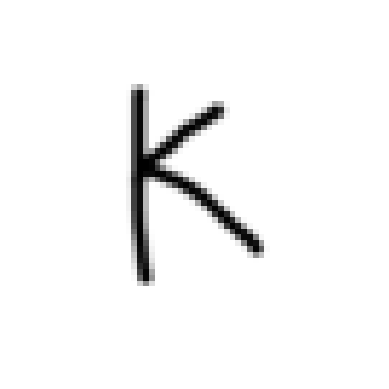

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



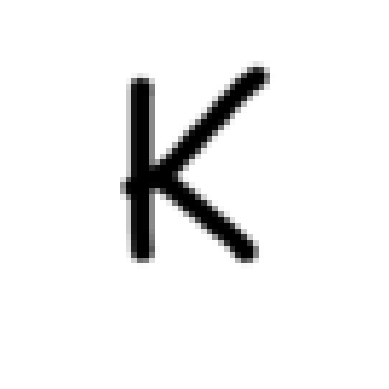

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



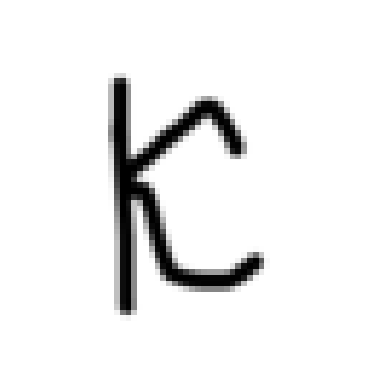

Predicted probabilities:
K: 0.9999
L: 0.0001
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



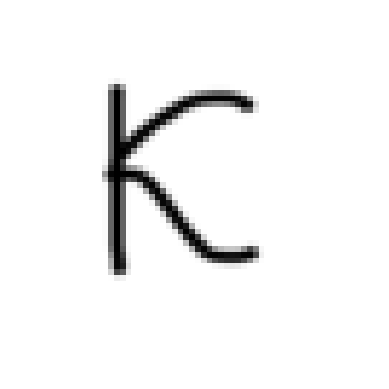

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



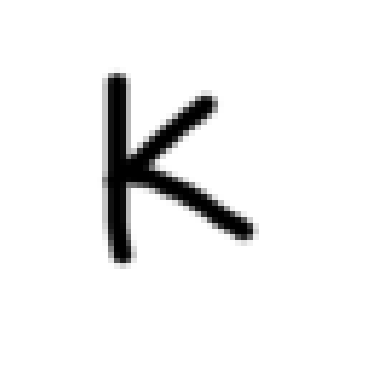

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



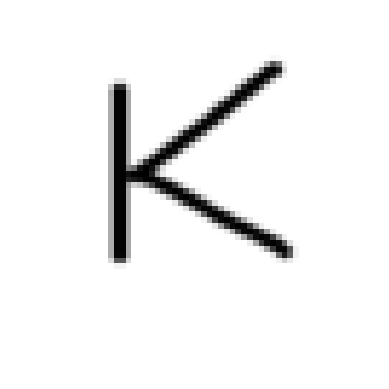

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



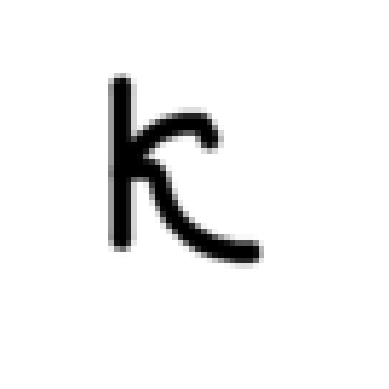

Predicted probabilities:
K: 0.9471
L: 0.0528
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



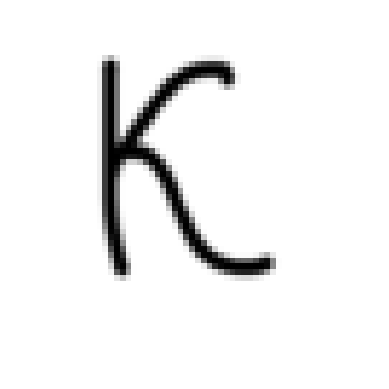

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



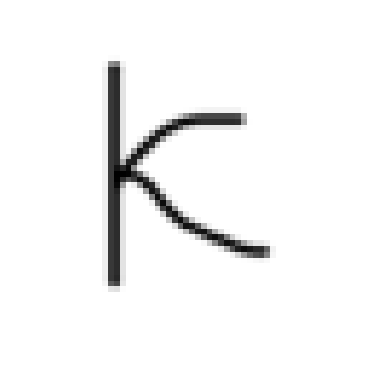

Predicted probabilities:
K: 0.9941
L: 0.0059
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



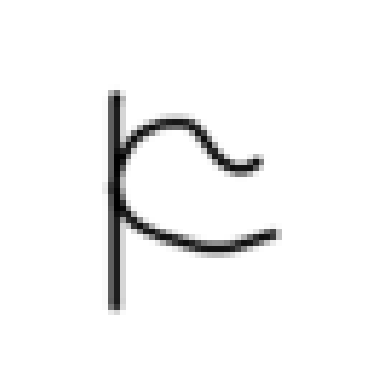

Predicted probabilities:
K: 0.0180
L: 0.1902
M: 0.6083
N: 0.1835
True Label: K
Predicted Label: M



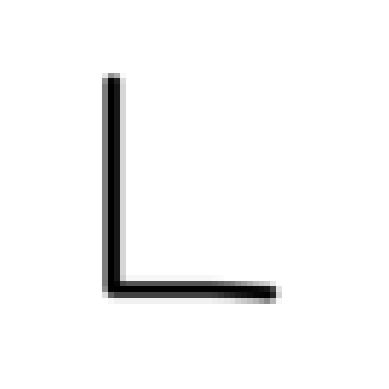

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



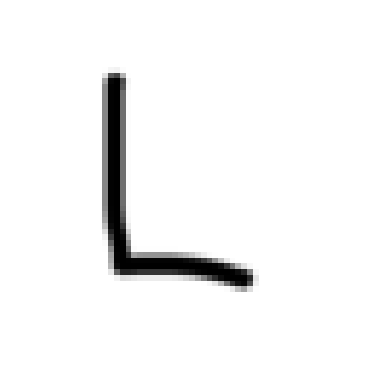

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



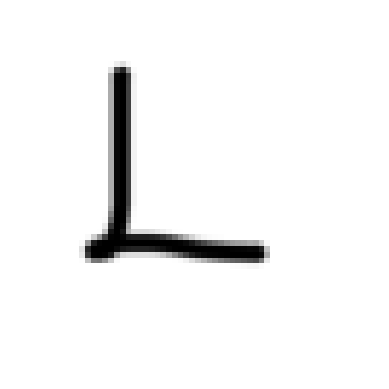

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



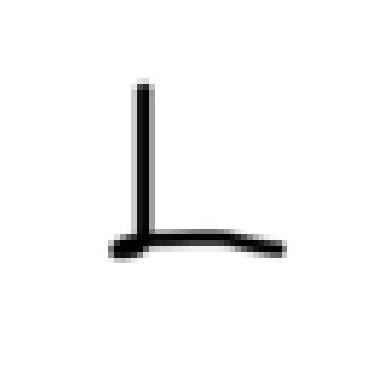

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



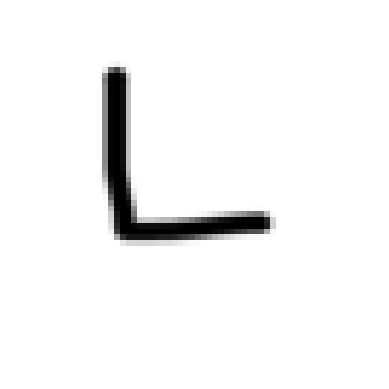

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



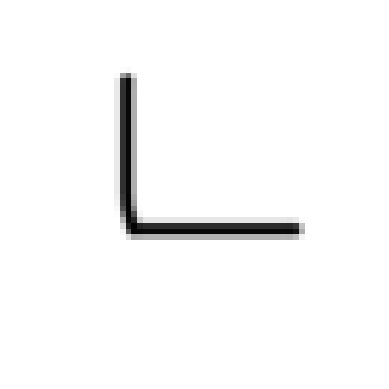

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



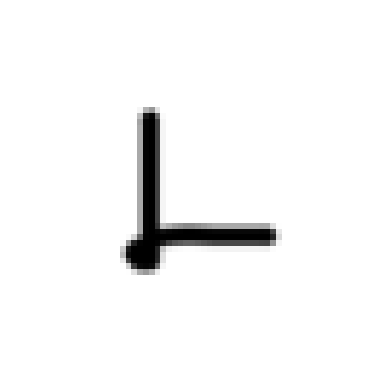

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



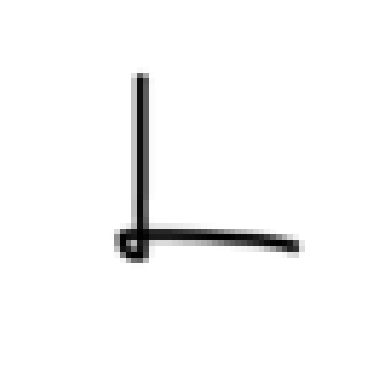

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



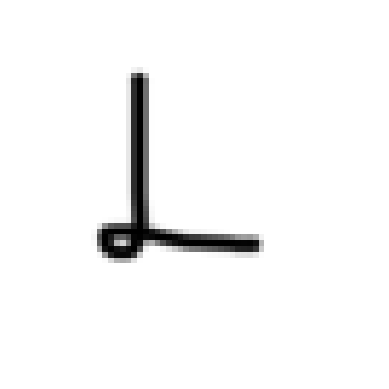

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



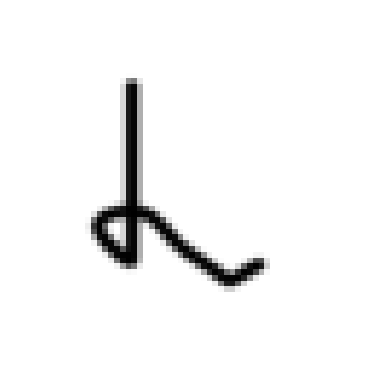

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



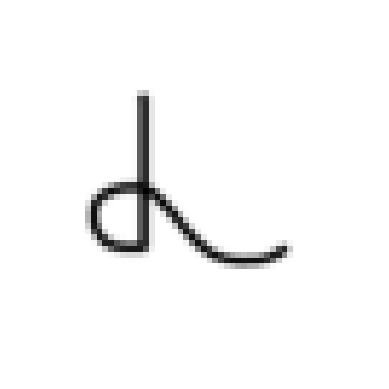

Predicted probabilities:
K: 0.0041
L: 0.9958
M: 0.0001
N: 0.0000
True Label: L
Predicted Label: L



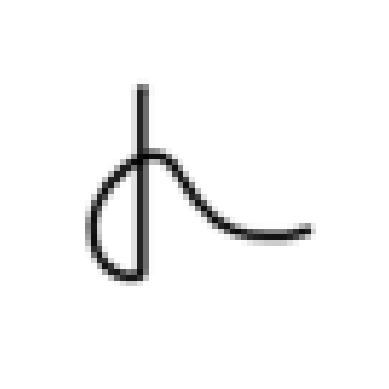

Predicted probabilities:
K: 0.8471
L: 0.0073
M: 0.1384
N: 0.0072
True Label: L
Predicted Label: K



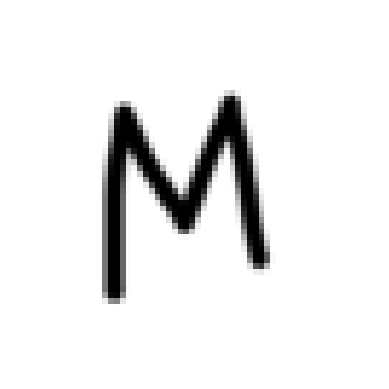

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



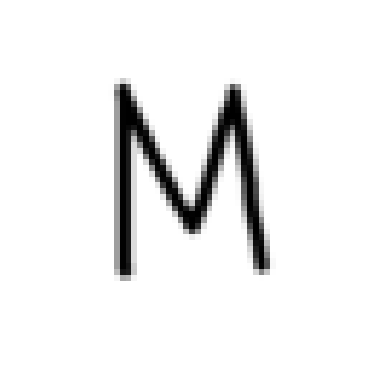

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



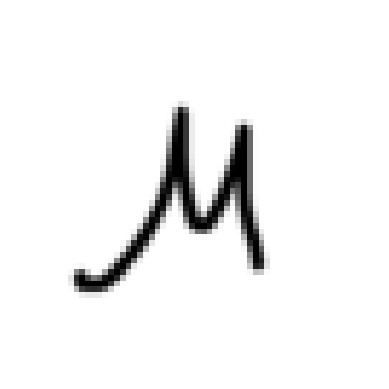

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9999
N: 0.0001
True Label: M
Predicted Label: M



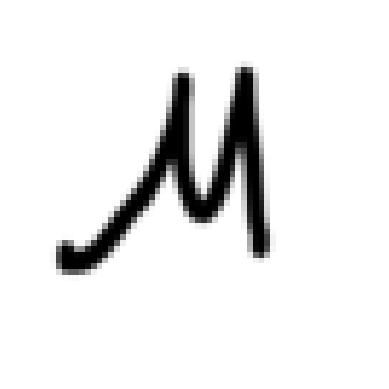

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



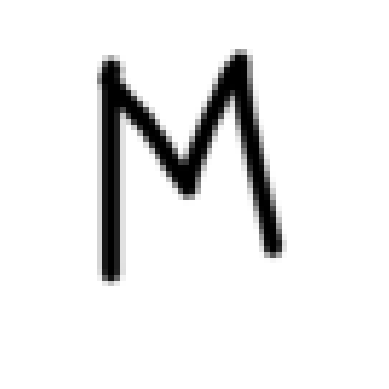

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9998
N: 0.0002
True Label: M
Predicted Label: M



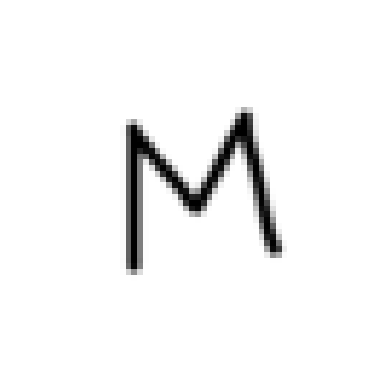

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



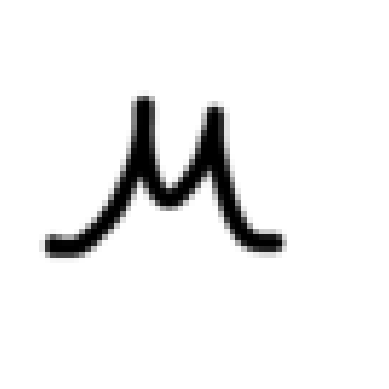

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



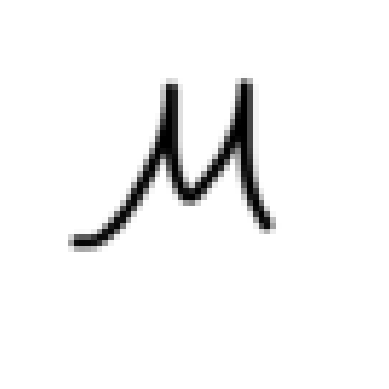

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



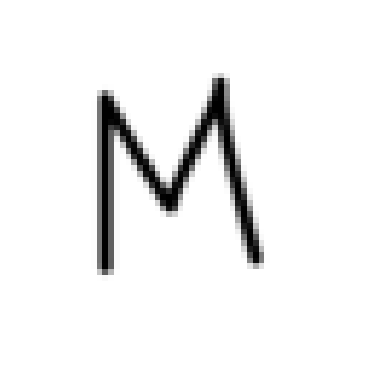

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



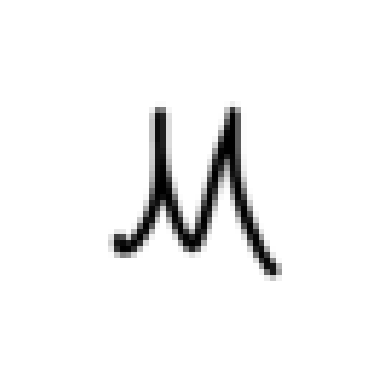

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



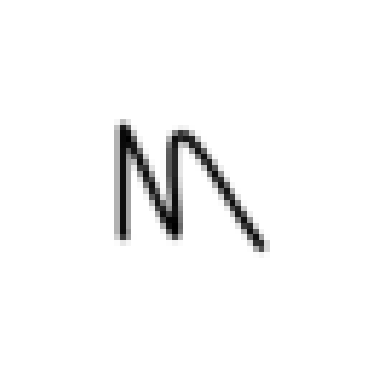

Predicted probabilities:
K: 0.0003
L: 0.0005
M: 0.9745
N: 0.0246
True Label: M
Predicted Label: M



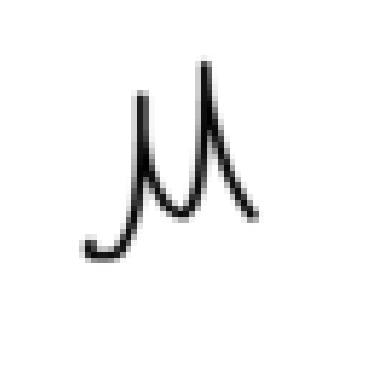

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9999
N: 0.0001
True Label: M
Predicted Label: M



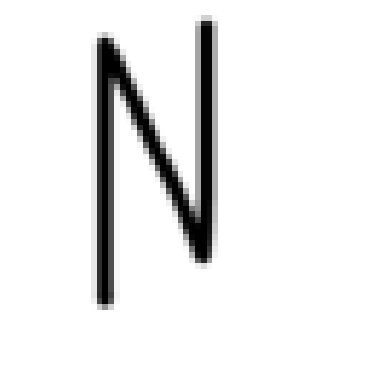

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0000
N: 1.0000
True Label: N
Predicted Label: N



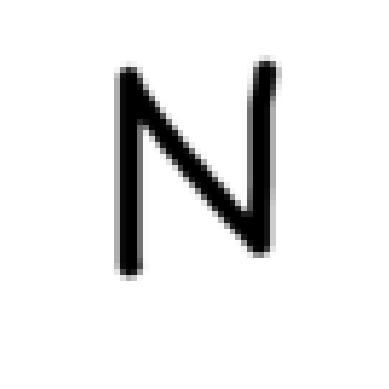

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0000
N: 1.0000
True Label: N
Predicted Label: N



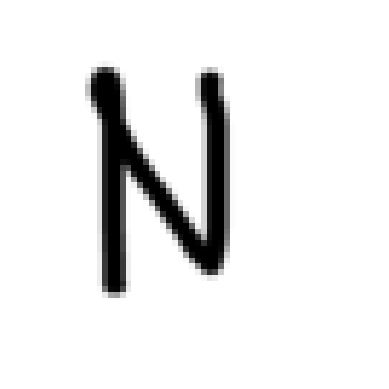

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0000
N: 1.0000
True Label: N
Predicted Label: N



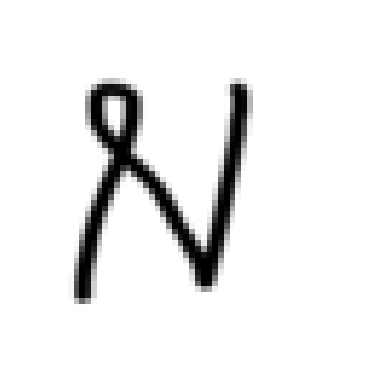

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0002
N: 0.9998
True Label: N
Predicted Label: N



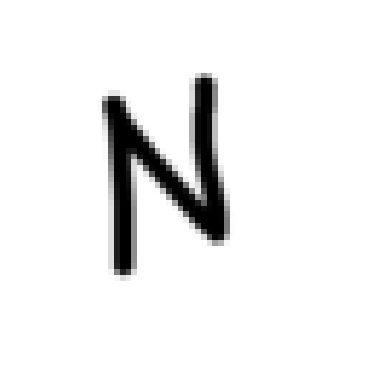

Predicted probabilities:
K: 0.0054
L: 0.0000
M: 0.0000
N: 0.9946
True Label: N
Predicted Label: N



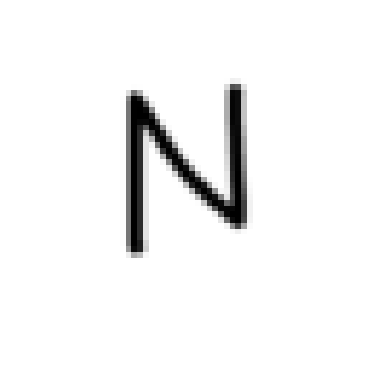

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0112
N: 0.9888
True Label: N
Predicted Label: N



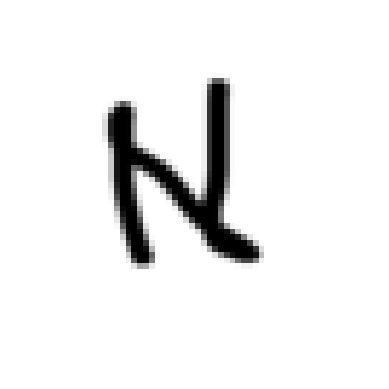

Predicted probabilities:
K: 0.0176
L: 0.0000
M: 0.0001
N: 0.9822
True Label: N
Predicted Label: N



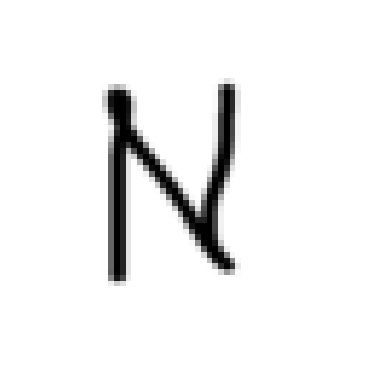

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0000
N: 1.0000
True Label: N
Predicted Label: N



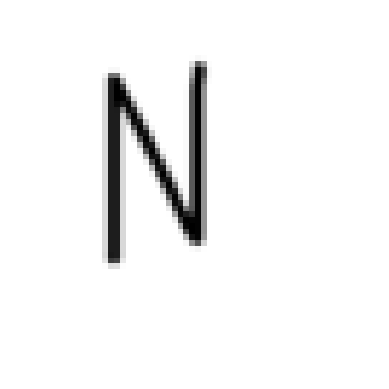

Predicted probabilities:
K: 0.0031
L: 0.0000
M: 0.0006
N: 0.9963
True Label: N
Predicted Label: N



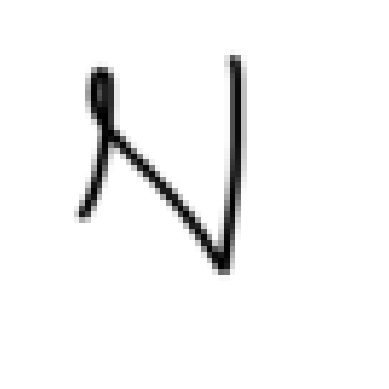

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0001
N: 0.9999
True Label: N
Predicted Label: N



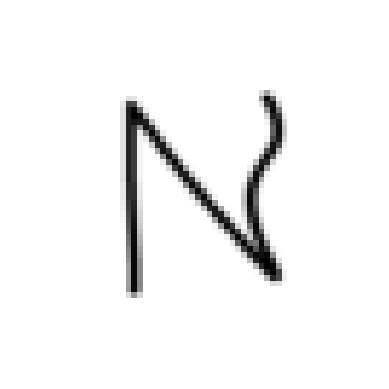

Predicted probabilities:
K: 0.0021
L: 0.0000
M: 0.0284
N: 0.9695
True Label: N
Predicted Label: N



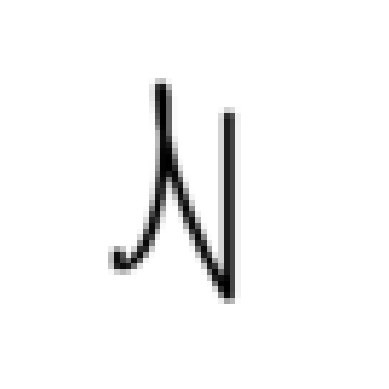

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0000
N: 1.0000
True Label: N
Predicted Label: N



In [ ]:
#свёрточная нейросеть
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv_layers = nn.Sequential(
            # Первый свёрточный блок
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # 1 канал -> 32 фильтра
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Снижение размера (64x64 -> 32x32)

            # Второй свёрточный блок
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 32 -> 64 фильтра
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Снижение размера (32x32 -> 16x16)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 16 * 16, 256),  # 64 фильтра на 16x16 -> 256 нейронов
            nn.ReLU(),
            nn.Linear(256, 4),  # 4 нейрона для предсказания классов
            nn.LogSoftmax(dim=1)  # Логарифмическая вероятность
        )

    def forward(self, x):
        x = self.conv_layers(x)  # Прогон через свёрточные слои
        x = x.view(x.size(0), -1)  # Разворачиваем тензор в вектор для полносвязных слоёв
        x = self.fc_layers(x)  # Прогон через полносвязные слои
        return x


# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)), # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = ConvNet()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adam использует метод статистически градиентного спуска

    epochs = 50
    iteration = 0
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            if (iteration + 1) % 10 == 0:
                model.eval() # Для оценки
                outputs = model(inputs)
                loss = F.nll_loss(outputs, labels)
                accuracy = correct / total * 100
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")
            iteration += 1

    return model

# Тестирование
def test_model(model):
    root_dir = "/content/drive/MyDrive/dataset_test"

    # Отображение индексов классов в буквы
    class_names = {0: "K", 1: "L", 2: "M", 3: "N"}

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),  # Изменено на 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)

    for inputs, label in test_dataset:
        inputs = inputs.unsqueeze(0)  # Добавляем размерность для батча
        outputs = model(inputs)

        # Преобразуем логарифмические вероятности в вероятности
        probabilities = torch.exp(outputs)

        # Определяем индекс и название класса с максимальной вероятностью
        predicted_index = torch.argmax(probabilities, dim=1).item()
        predicted_label = class_names[predicted_index]

        # Визуализация изображения
        imshow(inputs.squeeze().cpu())
        print("Predicted probabilities:")
        for i, prob in enumerate(probabilities.squeeze()):
            print(f"{class_names[i]}: {prob:.4f}")
        print(f"True Label: {class_names[label]}")
        print(f"Predicted Label: {predicted_label}\n")


model = train_model()
test_model(model)


Epoch 1/50, Loss: 1.2346, Accuracy: 45.78%
Epoch 2/50, Loss: 0.6371, Accuracy: 76.71%
Epoch 3/50, Loss: 0.4263, Accuracy: 84.74%
Epoch 4/50, Loss: 0.2702, Accuracy: 90.76%
Epoch 5/50, Loss: 0.3068, Accuracy: 90.36%
Epoch 6/50, Loss: 0.1547, Accuracy: 95.18%
Epoch 7/50, Loss: 0.0866, Accuracy: 97.99%
Epoch 8/50, Loss: 0.0594, Accuracy: 99.20%
Epoch 9/50, Loss: 0.0396, Accuracy: 99.20%
Epoch 10/50, Loss: 0.0304, Accuracy: 99.60%
Epoch 11/50, Loss: 0.0232, Accuracy: 99.60%
Epoch 12/50, Loss: 0.0176, Accuracy: 99.60%
Epoch 13/50, Loss: 0.0170, Accuracy: 99.60%
Epoch 14/50, Loss: 0.0137, Accuracy: 99.60%
Epoch 15/50, Loss: 0.0096, Accuracy: 100.00%
Epoch 16/50, Loss: 0.0073, Accuracy: 100.00%
Epoch 17/50, Loss: 0.0060, Accuracy: 100.00%
Epoch 18/50, Loss: 0.0046, Accuracy: 100.00%
Epoch 19/50, Loss: 0.0041, Accuracy: 100.00%
Epoch 20/50, Loss: 0.0037, Accuracy: 100.00%
Epoch 21/50, Loss: 0.0029, Accuracy: 100.00%
Epoch 22/50, Loss: 0.0026, Accuracy: 100.00%
Epoch 23/50, Loss: 0.0025, Accura

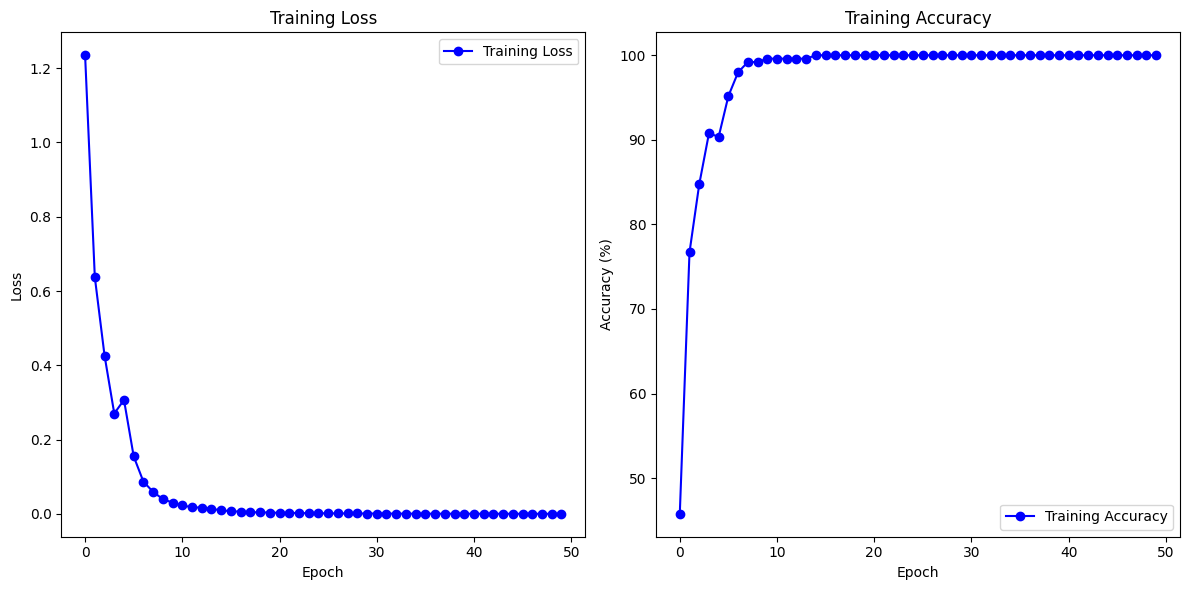

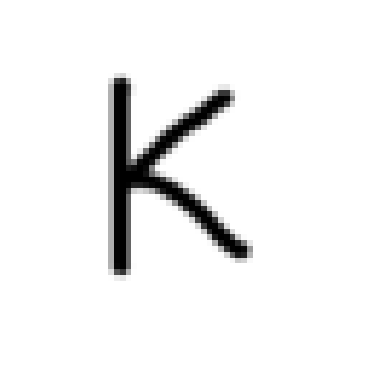

Predicted probabilities:
K: 1.0000
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



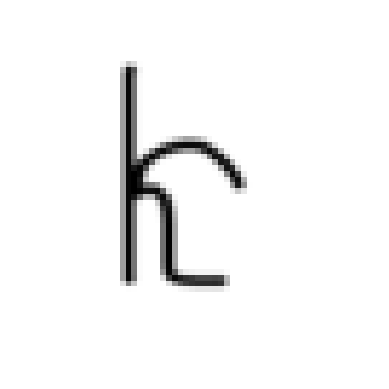

Predicted probabilities:
K: 0.0000
L: 0.9404
M: 0.0001
N: 0.0596
True Label: K
Predicted Label: L



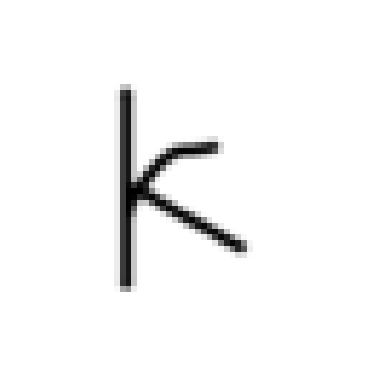

Predicted probabilities:
K: 0.4752
L: 0.5235
M: 0.0000
N: 0.0013
True Label: K
Predicted Label: L



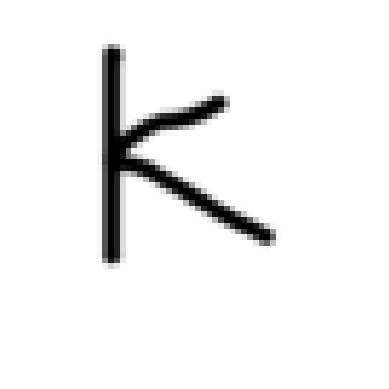

Predicted probabilities:
K: 0.9999
L: 0.0000
M: 0.0000
N: 0.0000
True Label: K
Predicted Label: K



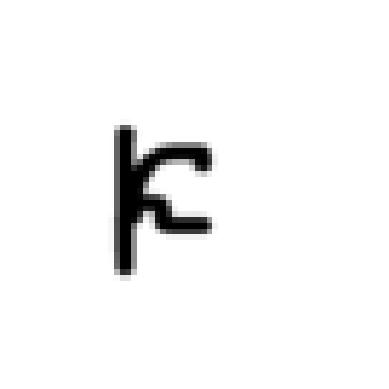

Predicted probabilities:
K: 0.0374
L: 0.9613
M: 0.0000
N: 0.0012
True Label: K
Predicted Label: L



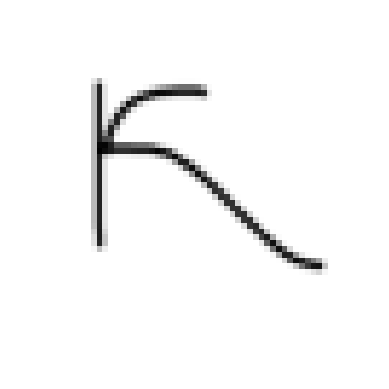

Predicted probabilities:
K: 0.4313
L: 0.0000
M: 0.4690
N: 0.0997
True Label: K
Predicted Label: M



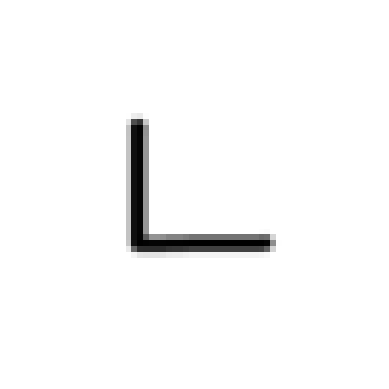

Predicted probabilities:
K: 0.0001
L: 0.9999
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



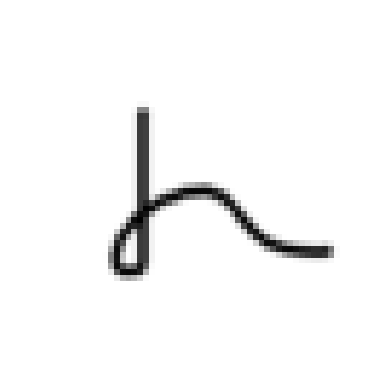

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



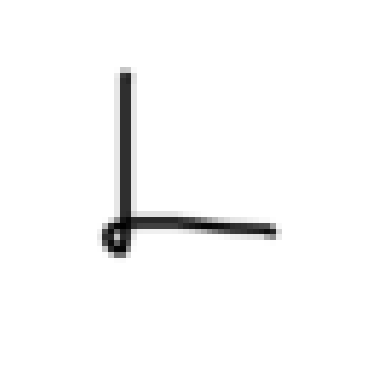

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



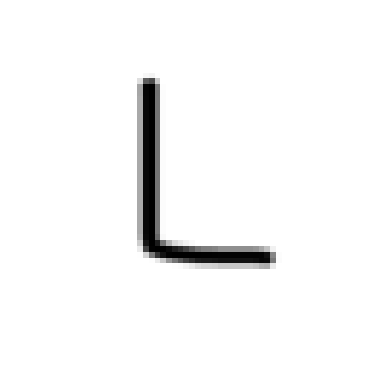

Predicted probabilities:
K: 0.0000
L: 1.0000
M: 0.0000
N: 0.0000
True Label: L
Predicted Label: L



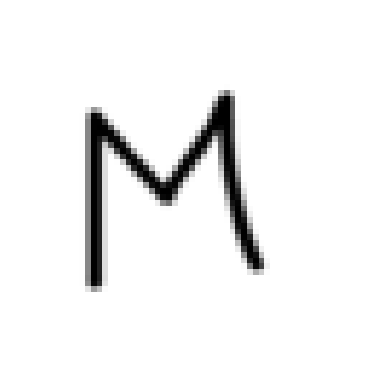

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



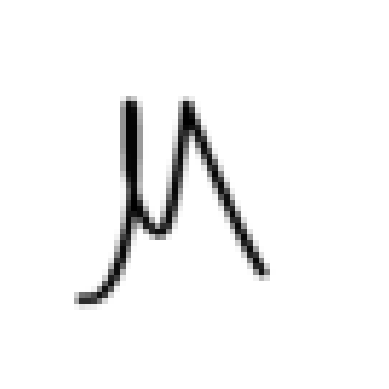

Predicted probabilities:
K: 0.0046
L: 0.0000
M: 0.9954
N: 0.0000
True Label: M
Predicted Label: M



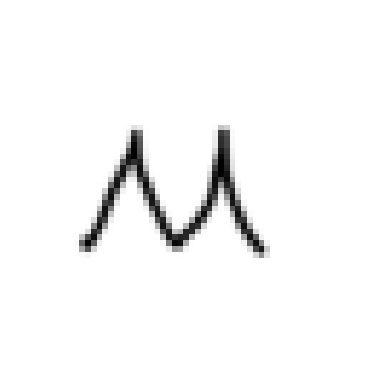

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



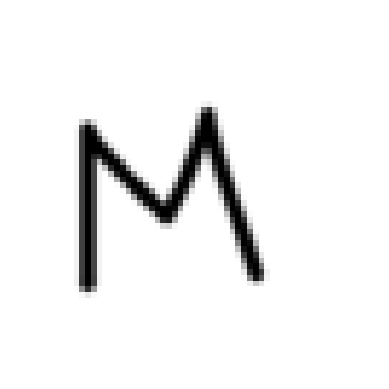

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



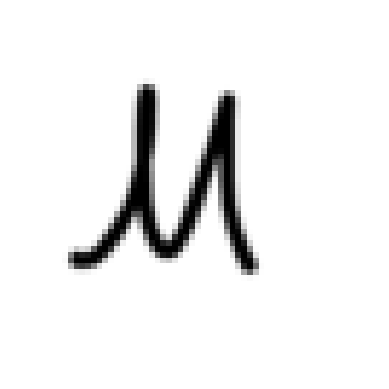

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



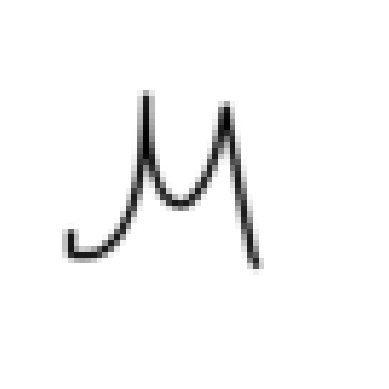

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



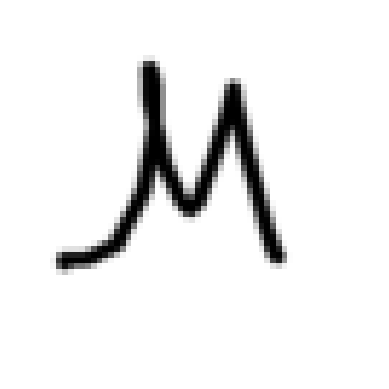

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



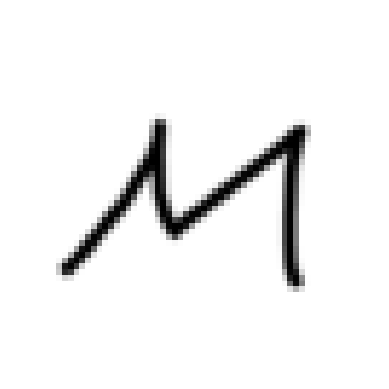

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 1.0000
N: 0.0000
True Label: M
Predicted Label: M



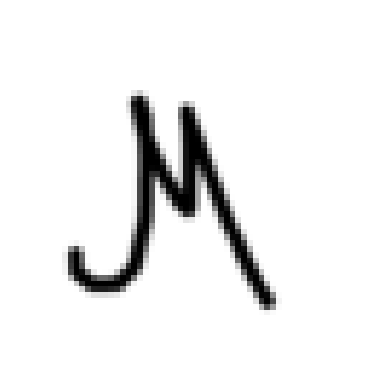

Predicted probabilities:
K: 0.9786
L: 0.0000
M: 0.0211
N: 0.0002
True Label: M
Predicted Label: K



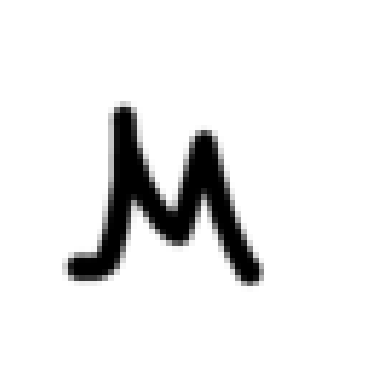

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.9999
N: 0.0001
True Label: M
Predicted Label: M



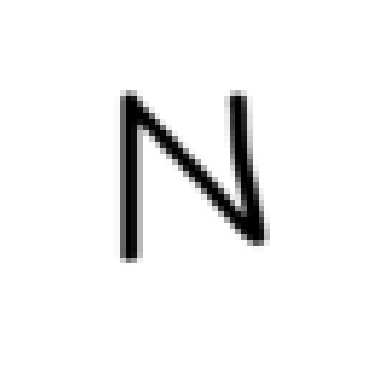

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.0641
N: 0.9359
True Label: N
Predicted Label: N



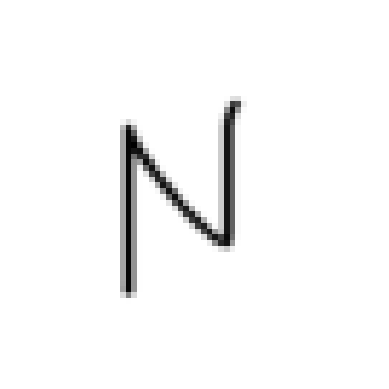

Predicted probabilities:
K: 0.0012
L: 0.0000
M: 0.0128
N: 0.9860
True Label: N
Predicted Label: N



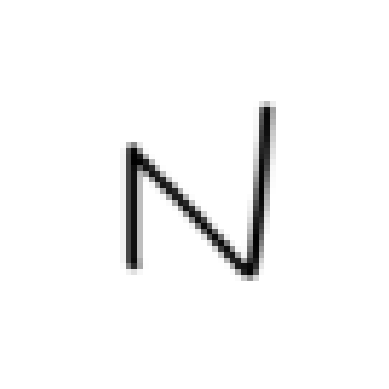

Predicted probabilities:
K: 0.0002
L: 0.0000
M: 0.0042
N: 0.9956
True Label: N
Predicted Label: N



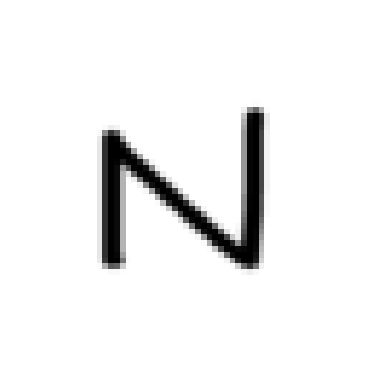

Predicted probabilities:
K: 0.0000
L: 0.0000
M: 0.1557
N: 0.8443
True Label: N
Predicted Label: N



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch_device = ("cpu")

def imshow(img):
    img = img.numpy()
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


class LettersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir, transform=transform)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label

# Архитектура
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 4),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


# Обучение
def train_model():
    root_dir = "/content/drive/MyDrive/dataset"

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = LettersDataset(root_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = ConvNet()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    epochs = 50

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        epoch_loss = 0.0

        for _, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(torch_device), labels.to(torch_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # Сохраняем средний loss и точность для текущей эпохи
        train_losses.append(epoch_loss / len(dataloader))
        train_accuracies.append(correct / total * 100)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss / len(dataloader):.4f}, Accuracy: {correct / total * 100:.2f}%")

    # Графики потерь и точности
    plt.figure(figsize=(12, 6))

    # Потери
    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), train_losses, label='Training Loss', color='blue', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Точность
    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), train_accuracies, label='Training Accuracy', color='blue', marker='o')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return model

# Тестирование
def test_model(model):
    root_dir = "/content/drive/MyDrive/dataset_test"

    class_names = {0: "K", 1: "L", 2: "M", 3: "N"}

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    test_dataset = LettersDataset(root_dir, transform=transform)

    for inputs, label in test_dataset:
        inputs = inputs.unsqueeze(0)
        outputs = model(inputs)

        probabilities = torch.exp(outputs)

        predicted_index = torch.argmax(probabilities, dim=1).item()
        predicted_label = class_names[predicted_index]

        imshow(inputs.squeeze().cpu())
        print("Predicted probabilities:")
        for i, prob in enumerate(probabilities.squeeze()):
            print(f"{class_names[i]}: {prob:.4f}")
        print(f"True Label: {class_names[label]}")
        print(f"Predicted Label: {predicted_label}\n")


model = train_model()
test_model(model)
